# Federated Learning on 20 Newsgroups
## Per-Class Shapley-based Free-Rider Detection

---

## 0. Environment Setup

In [1]:
# !git clone https://github.com/isaac-sun/20NEWS-FL.git 2>/dev/null; true
%cd /content/20NEWS-FL
!git pull origin main

/content/20NEWS-FL
From https://github.com/isaac-sun/20NEWS-FL
 * branch            main       -> FETCH_HEAD
Already up to date.


In [45]:
%pip install -q openpyxl tqdm seaborn

In [2]:
import torch, sklearn
print(f'PyTorch: {torch.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda': print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Using: {DEVICE}')

PyTorch: 2.10.0+cu128
scikit-learn: 1.6.1
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Using: cuda


---
## 1. Data Loading

In [3]:
# Fix: bypass figshare HTTP 403 for 20 Newsgroups by patching sklearn's _fetch_remote
import os, urllib.request
from sklearn.datasets import _base as _db
import sklearn.datasets._twenty_newsgroups as _ng

_MIRRORS = [
    "http://qwone.com/~jason/20Newsgroups/20news-bydate.tar.gz",
    "https://archive.org/download/20Newsgroups/20news-bydate.tar.gz",
]
_orig_fetch_remote = _db._fetch_remote

def _patched_fetch_remote(remote, dirname=None, n_retries=3, delay=1.0):
    dst = os.path.join(dirname or ".", remote.filename)
    if os.path.exists(dst):
        print(f"Using cached archive: {dst}")
        return dst
    for url in _MIRRORS:
        try:
            print(f"Downloading from mirror: {url}")
            urllib.request.urlretrieve(url, dst)
            print("Download complete.")
            return dst
        except Exception as e:
            print(f"  Mirror failed: {e}")
    # All mirrors failed, try original (may still 403)
    print("All mirrors failed, trying original URL...")
    return _orig_fetch_remote(remote, dirname=dirname, n_retries=n_retries, delay=delay)

_db._fetch_remote = _patched_fetch_remote
_ng._fetch_remote = _patched_fetch_remote
print("_fetch_remote patched: figshare will be redirected to mirror.")


_fetch_remote patched: figshare will be redirected to mirror.


In [4]:
import numpy as np
from utils.seed import set_seed
from data.newsgroups import load_newsgroups

set_seed(42)
train_ds, val_ds, test_ds, input_dim, train_labels = load_newsgroups(max_features=10000, val_ratio=0.1)
print(f'Input dim: {input_dim}, Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')
print(f'Classes: {len(np.unique(train_labels))}')

Input dim: 10000, Train: 10183, Val: 1131, Test: 7532
Classes: 20


---
## 2. Model & Partition

In [5]:
from models.mlp import MLP
from utils.partition import iid_partition
from torch.utils.data import Subset

NUM_CLIENTS = 10
model = MLP(input_dim, 256, 20).to(DEVICE)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

set_seed(42)
partition = iid_partition(train_ds, NUM_CLIENTS)
for cid in range(NUM_CLIENTS):
    print(f'  Client {cid}: {len(partition[cid])} samples')

MLP(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=20, bias=True)
  )
)
Parameters: 2,565,396
  Client 0: 1019 samples
  Client 1: 1019 samples
  Client 2: 1019 samples
  Client 3: 1018 samples
  Client 4: 1018 samples
  Client 5: 1018 samples
  Client 6: 1018 samples
  Client 7: 1018 samples
  Client 8: 1018 samples
  Client 9: 1018 samples


---
## 3. Attack Definitions (Paper-Aligned)

| Attack | Paper | Formula |
|--------|-------|---------|
| DFR | Fraboni [11] | g = sigma * t^{-gamma} * N(0,I) |
| SDFR | Zhu [12] | U_f = (norm(delta_t)/norm(delta_prev)) * delta_t |
| AFR | Zhu [12] | SDFR + sparse noise on d coords, magnitude from E[cos beta] |

---
## 4. Run All Experiments

In [7]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import copy, matplotlib.pyplot as plt, pandas as pd, seaborn as sns
from collections import deque
from tqdm import tqdm
from config import Config
from utils.seed import set_seed
from data.newsgroups import load_newsgroups
from models.mlp import MLP
from fl.client import FLClient
from fl.server import FLServer
from fl.aggregation import fedavg_aggregate
from attacks.dfr import dfr_attack, estimate_dfr_sigma
from attacks.sdfr import sdfr_attack
from attacks.afr import afr_attack, AFRState
from contribution.shapley import (
    estimate_round_shapley_per_class, per_class_to_overall,
    compute_class_metrics, _class_weights_from_loader
)
from detection.utility_score import UtilityScoreTracker
from utils.partition import iid_partition, non_iid_partition
from utils.export import export_results
from torch.utils.data import DataLoader, Subset

import numpy as np
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")


Using device: cuda


In [8]:
def apply_attack(attack_type, global_sd, global_history, cfg,
                 round_num=1, dfr_sigma_est=None,
                 afr_state=None, val_loss_t=None):
    """Generate free-rider update. Returns (update, metadata_dict)."""
    if attack_type == "dfr":
        sigma = cfg.dfr_sigma
        if cfg.dfr_estimate_sigma and dfr_sigma_est is not None:
            sigma = dfr_sigma_est
        update = dfr_attack(global_sd, sigma=sigma,
                            round_num=round_num, gamma=cfg.dfr_gamma)
        return update, {}
    elif attack_type == "sdfr":
        update = sdfr_attack(global_sd, global_history)
        return update, {}
    elif attack_type == "afr":
        e_cos_beta = 0.0
        if cfg.afr_e_cos_beta_override is not None:
            e_cos_beta = cfg.afr_e_cos_beta_override
        elif afr_state is not None and val_loss_t is not None:
            e_cos_beta = afr_state.get_e_cos_beta(val_loss_t)
        mean_base_norm = None
        if afr_state is not None:
            mean_base_norm = afr_state.get_mean_base_norm()
        update, base_norm = afr_attack(
            global_sd, global_history,
            n_total=cfg.num_clients,
            e_cos_beta=e_cos_beta,
            mean_base_norm=mean_base_norm,
            noisy_frac=cfg.afr_noisy_frac,
        )
        return update, {"afr_base_norm": base_norm}
    raise ValueError(f"Unknown: {attack_type}")


def run_experiment(config, train_dataset, val_dataset, test_dataset,
                   input_dim, train_labels):
    """Returns: round_details, summary, test_accs, test_losses, per_class_records"""
    set_seed(config.seed)
    print(f"\n{'='*60}")
    print(f"Experiment: {config.experiment_name} | Attack: {config.attack_type}")
    print(f"{'='*60}")

    if config.iid:
        partition = iid_partition(train_dataset, config.num_clients)
    else:
        partition = non_iid_partition(train_labels, config.num_clients)

    client_datasets = {cid: Subset(train_dataset, idx) for cid, idx in partition.items()}
    model_fn = lambda: MLP(input_dim, config.hidden_dim, config.num_classes).to(config.device)
    model = model_fn()
    server = FLServer(model, val_dataset, test_dataset, config)
    clients = {cid: FLClient(cid, client_datasets[cid], model_fn, config)
               for cid in range(config.num_clients)}

    num_mal = int(config.num_clients * config.malicious_ratio) if config.attack_type != "none" else 0
    malicious_ids = set(range(num_mal))

    utility_tracker = UtilityScoreTracker(alpha=config.utility_alpha)
    round_details = []
    per_class_records = []
    test_accs, test_losses = [], []
    participation_counts = {cid: 0 for cid in range(config.num_clients)}
    cumulative_sv = {cid: 0.0 for cid in range(config.num_clients)}
    cumulative_class_var = {cid: [] for cid in range(config.num_clients)}
    cumulative_pos_sum = {cid: [] for cid in range(config.num_clients)}

    # Attack state trackers
    dfr_sigma_est = None
    afr_state = AFRState(ema_alpha=config.afr_base_norm_ema_alpha) if config.attack_type == "afr" else None

    val_loader = DataLoader(val_dataset, batch_size=config.batch_size)
    eval_model = model_fn()
    class_weights = _class_weights_from_loader(val_loader, config.num_classes)

    for round_t in tqdm(range(config.num_rounds), desc=config.experiment_name):
        selected = server.select_clients(config.num_clients, config.participation_ratio)
        global_sd = server.get_global_state_dict()
        global_history = list(server.global_history)

        # DFR sigma auto-estimation (once, from initial global delta)
        if config.attack_type == "dfr" and dfr_sigma_est is None and config.dfr_estimate_sigma:
            est = estimate_dfr_sigma(global_sd, global_history)
            if est is not None:
                dfr_sigma_est = est
                print(f"  DFR sigma auto-estimated: {dfr_sigma_est:.6f}")

        # AFR: pre-attack validation loss for E[cos β] estimation
        val_loss_t = None
        if config.attack_type == "afr":
            val_loss_t, _ = server.evaluate_val()
            if afr_state is not None and afr_state.val_loss_init is None:
                afr_state.val_loss_init = val_loss_t
                print(f"  AFR val_loss_init: {val_loss_t:.4f}")

        updates = {}
        afr_base_norms = []
        for cid in selected:
            participation_counts[cid] += 1
            if cid in malicious_ids:
                update, meta = apply_attack(
                    config.attack_type, global_sd, global_history, config,
                    round_num=round_t + 1,
                    dfr_sigma_est=dfr_sigma_est,
                    afr_state=afr_state,
                    val_loss_t=val_loss_t,
                )
                updates[cid] = update
                if "afr_base_norm" in meta:
                    afr_base_norms.append(meta["afr_base_norm"])
            else:
                updates[cid] = clients[cid].train(global_sd)

        # Post-attack: update AFR state
        if afr_state is not None and val_loss_t is not None and afr_base_norms:
            afr_state.update(val_loss_t, float(np.mean(afr_base_norms)))

        per_class_sv = estimate_round_shapley_per_class(
            eval_model, updates, global_sd, val_loader,
            num_classes=config.num_classes, server_lr=config.server_lr,
            num_mc_samples=config.num_mc_samples, device=config.device,
        )
        shapley_vals = per_class_to_overall(per_class_sv, class_weights)
        class_metrics = compute_class_metrics(per_class_sv)
        utility_tracker.update(shapley_vals)

        new_sd = fedavg_aggregate(global_sd, updates, config.server_lr)
        server.update_global_model(new_sd)

        test_loss, test_acc = server.evaluate()
        test_accs.append(test_acc)
        test_losses.append(test_loss)

        if round_t % 5 == 0 or round_t == config.num_rounds - 1:
            print(f"  Round {round_t:>2d}: acc={test_acc:.4f}  loss={test_loss:.4f}")

        for cid in selected:
            sv = shapley_vals.get(cid, 0.0)
            cumulative_sv[cid] += sv
            pc = participation_counts[cid]
            cm = class_metrics.get(cid, {})
            cls_var = cm.get("class_sv_variance", 0.0)
            pos_sum = cm.get("positive_class_sv_sum", 0.0)
            cumulative_class_var[cid].append(cls_var)
            cumulative_pos_sum[cid].append(pos_sum)

            round_details.append({
                "experiment_name": config.experiment_name,
                "attack_type": config.attack_type,
                "round": round_t,
                "client_id": cid,
                "is_malicious": cid in malicious_ids,
                "participation_count_so_far": pc,
                "round_shapley_value": sv,
                "cumulative_shapley_value": cumulative_sv[cid],
                "mean_shapley_value": cumulative_sv[cid] / pc,
                "class_sv_variance": cls_var,
                "positive_class_sv_sum": pos_sum,
                "mean_class_sv_variance": float(np.mean(cumulative_class_var[cid])),
                "mean_positive_class_sv_sum": float(np.mean(cumulative_pos_sum[cid])),
                "utility_score": utility_tracker.scores.get(cid, 0.0),
            })

            pc_arr = per_class_sv.get(cid, np.zeros(config.num_classes))
            rec = {
                "experiment_name": config.experiment_name,
                "round": round_t,
                "client_id": cid,
                "is_malicious": cid in malicious_ids,
            }
            for c in range(config.num_classes):
                rec[f"class_{c}"] = float(pc_arr[c])
            per_class_records.append(rec)

    honest_ids = [c for c in range(config.num_clients) if c not in malicious_ids]
    def _avg_mean_sv(ids):
        vals = [cumulative_sv[c] / max(participation_counts[c], 1) for c in ids]
        return float(np.mean(vals)) if vals else 0.0
    def _avg_cum_sv(ids):
        return float(np.mean([cumulative_sv[c] for c in ids])) if ids else 0.0
    def _avg_metric(ids, store):
        vals = [float(np.mean(store[c])) if store[c] else 0.0 for c in ids]
        return float(np.mean(vals)) if vals else 0.0

    summary = {
        "experiment_name": config.experiment_name,
        "attack_type": config.attack_type,
        "malicious_ratio": config.malicious_ratio if num_mal > 0 else 0.0,
        "final_global_accuracy": test_accs[-1],
        "final_global_loss": test_losses[-1],
        "avg_round_shapley_honest": _avg_mean_sv(honest_ids),
        "avg_round_shapley_malicious": _avg_mean_sv(list(malicious_ids)),
        "avg_cumulative_shapley_honest": _avg_cum_sv(honest_ids),
        "avg_cumulative_shapley_malicious": _avg_cum_sv(list(malicious_ids)),
        "shapley_gap": _avg_mean_sv(honest_ids) - _avg_mean_sv(list(malicious_ids)),
        "avg_class_sv_variance_honest": _avg_metric(honest_ids, cumulative_class_var),
        "avg_class_sv_variance_malicious": _avg_metric(list(malicious_ids), cumulative_class_var),
        "avg_positive_class_sv_sum_honest": _avg_metric(honest_ids, cumulative_pos_sum),
        "avg_positive_class_sv_sum_malicious": _avg_metric(list(malicious_ids), cumulative_pos_sum),
        "attack_effective": "",
        "notes": "",
    }
    return round_details, summary, test_accs, test_losses, per_class_records


In [9]:
base_cfg = Config(
    num_clients=10, num_rounds=30, local_epochs=3, local_lr=0.001,
    server_lr=1.0, participation_ratio=0.8, batch_size=64,
    hidden_dim=256, num_classes=20, max_features=10000, val_ratio=0.1,
    malicious_ratio=0.4, num_mc_samples=30, seed=42,
    device=DEVICE, results_dir="results",
)

experiments = [
    ("baseline_no_attack", "none"),
    ("attack_dfr", "dfr"),
    ("attack_sdfr", "sdfr"),
    ("attack_afr", "afr"),
]

all_details, all_summaries, all_curves, all_pc = [], [], {}, []

set_seed(42)
train_ds, val_ds, test_ds, input_dim, train_labels = load_newsgroups(
    max_features=base_cfg.max_features, val_ratio=base_cfg.val_ratio
)

for exp_name, attack_type in experiments:
    cfg = copy.deepcopy(base_cfg)
    cfg.experiment_name = exp_name
    cfg.attack_type = attack_type
    details, summary, accs, losses, pc_records = run_experiment(
        cfg, train_ds, val_ds, test_ds, input_dim, train_labels
    )
    all_details.extend(details)
    all_summaries.append(summary)
    all_curves[exp_name] = {"acc": accs, "loss": losses}
    all_pc.extend(pc_records)

baseline_acc = all_summaries[0]["final_global_accuracy"]
for s in all_summaries[1:]:
    drop = baseline_acc - s["final_global_accuracy"]
    s["attack_effective"] = drop > 0.02
    s["notes"] = f"accuracy drop: {drop:.4f}"

df = pd.DataFrame(all_details)
df_pc = pd.DataFrame(all_pc)
class_cols = [f"class_{c}" for c in range(20)]
attack_names = ["attack_dfr", "attack_sdfr", "attack_afr"]

print("\n" + "=" * 72)
print("All experiments done!")
print("=" * 72)


Experiment: baseline_no_attack | Attack: none


baseline_no_attack:   3%|▎         | 1/30 [00:11<05:36, 11.59s/it]

  Round  0: acc=0.4599  loss=2.9227


baseline_no_attack:  20%|██        | 6/30 [00:52<03:22,  8.42s/it]

  Round  5: acc=0.6536  loss=1.7967


...

  Round 20: acc=0.6747  loss=1.1127


attack_afr:  87%|████████▋ | 26/30 [03:31<00:32,  8.12s/it]

  Round 25: acc=0.6774  loss=1.1482


attack_afr: 100%|██████████| 30/30 [04:03<00:00,  8.13s/it]

  Round 29: acc=0.6751  loss=1.1970

All experiments done!


---
## 5. Summary Table

In [22]:
df_summary = pd.DataFrame(all_summaries)
df_summary[['experiment_name','final_global_accuracy','final_global_loss',
    'shapley_gap','avg_class_sv_variance_honest','avg_class_sv_variance_malicious',
    'avg_positive_class_sv_sum_honest','avg_positive_class_sv_sum_malicious']]

,experiment_name,final_global_accuracy,final_global_loss,shapley_gap,avg_class_sv_variance_honest,avg_class_sv_variance_malicious,avg_positive_class_sv_sum_honest,avg_positive_class_sv_sum_malicious
0,baseline_no_attack,0.689326,1.094795,0.008892,0.001295,0.000000,0.380464,0.000000
1,attack_dfr,0.664631,1.173681,0.071123,0.003046,0.014124,0.868098,0.051349
2,attack_sdfr,0.675385,1.198460,-0.000401,0.001544,0.000497,0.397132,0.234415
3,attack_afr,0.675119,1.197012,-0.000534,0.001582,0.000552,0.401290,0.239282


In [23]:
import os
import matplotlib.pyplot as plt
import re

os.makedirs("results", exist_ok=True)

# 为了让你无需手动修改每一个画图的 Cell，这里通过 "拦截(Monkey Patch)" matplotlib 的 show() 函数来实现全自动保存
if getattr(plt, "_is_patched", False) is False:
    _original_show = plt.show

    _fig_counter = 1
    def _hooked_show(*args, **kwargs):
        global _fig_counter
        fig = plt.gcf()
        
        # 尝试提取图片标题作为文件名
        title = ""
        if fig._suptitle and fig._suptitle.get_text():
            title = fig._suptitle.get_text()
        elif fig.axes and fig.axes[0].get_title():
            title = fig.axes[0].get_title()
            
        if title:
            # 清理特殊字符
            safe_title = re.sub(r'[^a-zA-Z0-9_\-]', '_', title)[:40].strip('_')
            filename = f"results/fig_{_fig_counter:02d}_{safe_title}.png"
        else:
            filename = f"results/fig_{_fig_counter:02d}.png"
            
        # 自动保存进 results 目录
        fig.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"✅ 图表已自动保存至: {filename}")
        _fig_counter += 1
        
        return _original_show(*args, **kwargs)

    plt.show = _hooked_show
    plt._is_patched = True
    print("🎨 自动保存图表机制已启动！后续所有由 plt.show() 生成的图表都将自动保存在 results 文件夹中。")
else:
    print("🎨 自动保存图表机制已激活。")

🎨 自动保存图表机制已启动！后续所有由 plt.show() 生成的图表都将自动保存在 results 文件夹中。


---
## 6. Accuracy & Loss Curves

✅ 图表已自动保存至: results/fig_01_Global_Test_Accuracy.png


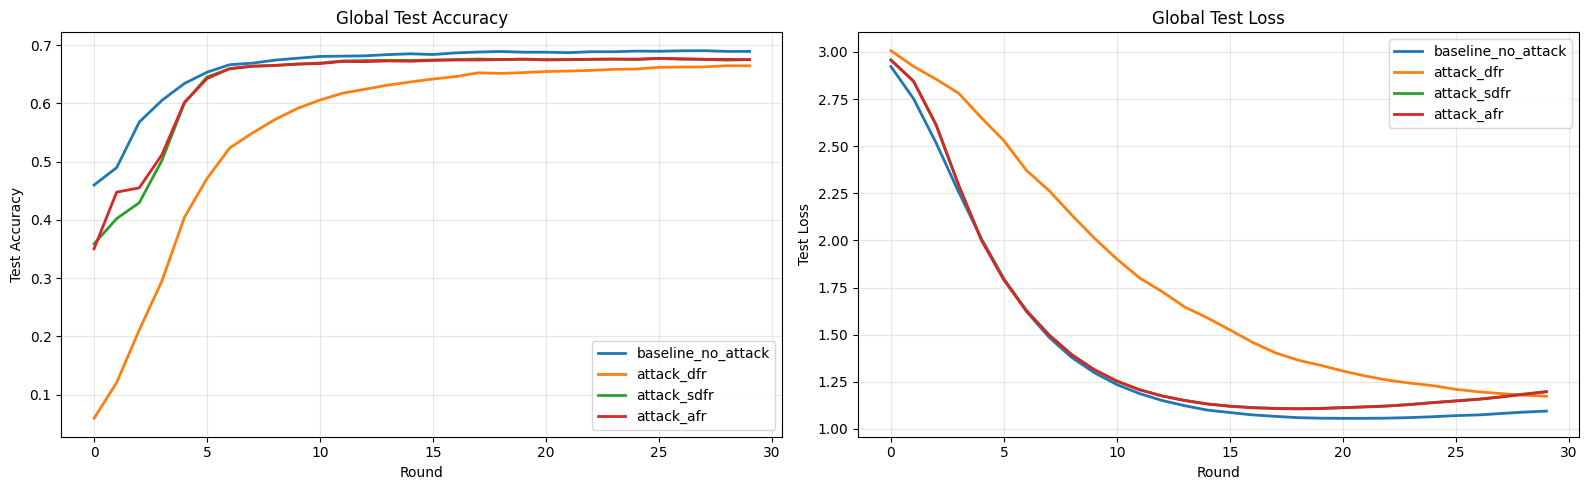

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
for name, data in all_curves.items():
    ax1.plot(data["acc"], label=name, linewidth=2)
ax1.set_xlabel("Round"); ax1.set_ylabel("Test Accuracy")
ax1.set_title("Global Test Accuracy"); ax1.legend(); ax1.grid(True, alpha=0.3)
for name, data in all_curves.items():
    ax2.plot(data["loss"], label=name, linewidth=2)
ax2.set_xlabel("Round"); ax2.set_ylabel("Test Loss")
ax2.set_title("Global Test Loss"); ax2.legend(); ax2.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

---
## 7. Round-Level Shapley: Honest vs Malicious

✅ 图表已自动保存至: results/fig_02_Round-Level_Shapley_Value.png


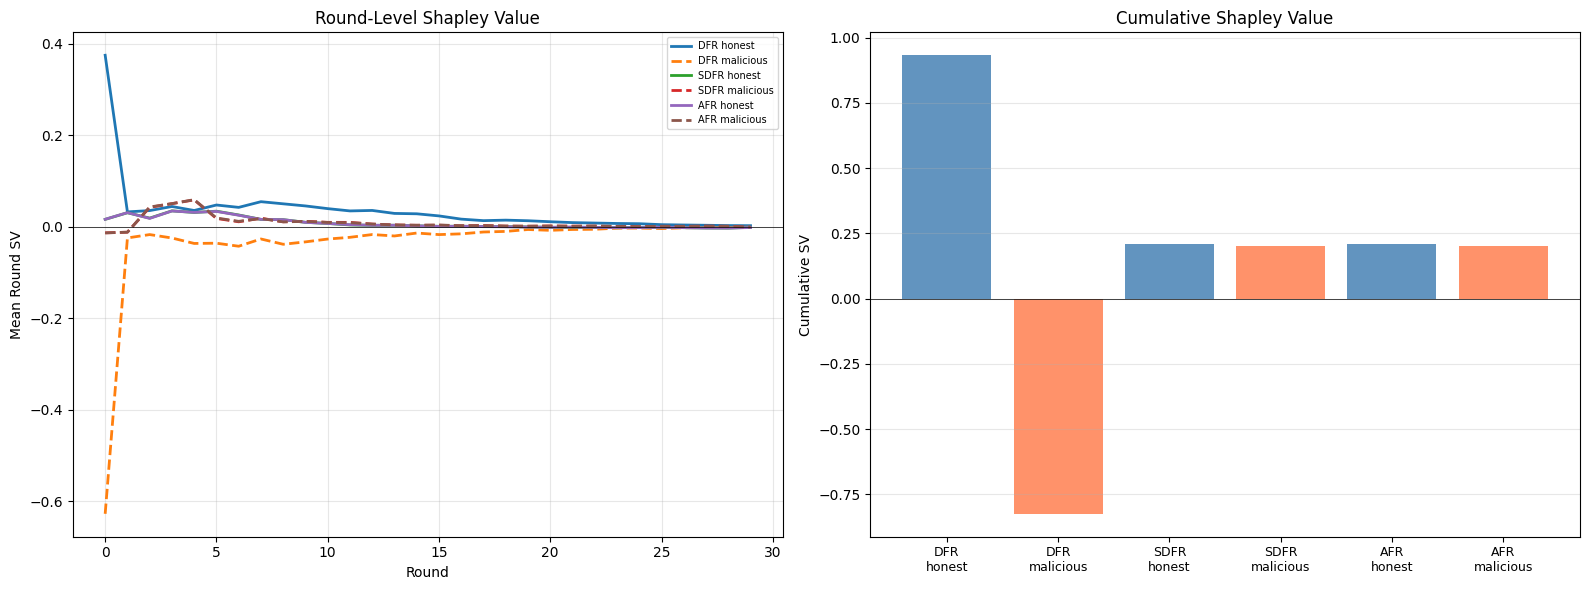

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for exp_name in attack_names:
    sub = df[df["experiment_name"] == exp_name]
    honest = sub[~sub["is_malicious"]].groupby("round")["round_shapley_value"].mean()
    mal = sub[sub["is_malicious"]].groupby("round")["round_shapley_value"].mean()
    label = exp_name.replace("attack_", "").upper()
    axes[0].plot(honest.index, honest.values, label=f"{label} honest", linewidth=2)
    axes[0].plot(mal.index, mal.values, ls="--", label=f"{label} malicious", linewidth=2)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].set_xlabel("Round"); axes[0].set_ylabel("Mean Round SV")
axes[0].set_title("Round-Level Shapley Value"); axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

bar_data = []
for exp_name in attack_names:
    sub = df[df["experiment_name"] == exp_name]
    last = sub[sub["round"] == sub["round"].max()]
    label = exp_name.replace("attack_", "").upper()
    h = last[~last["is_malicious"]]["cumulative_shapley_value"].mean()
    m = last[last["is_malicious"]]["cumulative_shapley_value"].mean()
    bar_data.append((f"{label}\nhonest", h, "steelblue"))
    bar_data.append((f"{label}\nmalicious", m, "coral"))
x = np.arange(len(bar_data))
axes[1].bar(x, [b[1] for b in bar_data], color=[b[2] for b in bar_data], alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels([b[0] for b in bar_data], fontsize=9)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].set_ylabel("Cumulative SV"); axes[1].set_title("Cumulative Shapley Value")
axes[1].grid(True, axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

---
## 8. Shapley Heatmap (Per-Client Per-Round)

✅ 图表已自动保存至: results/fig_03_Per-Client_Per-Round_Shapley_Value_Heatm.png


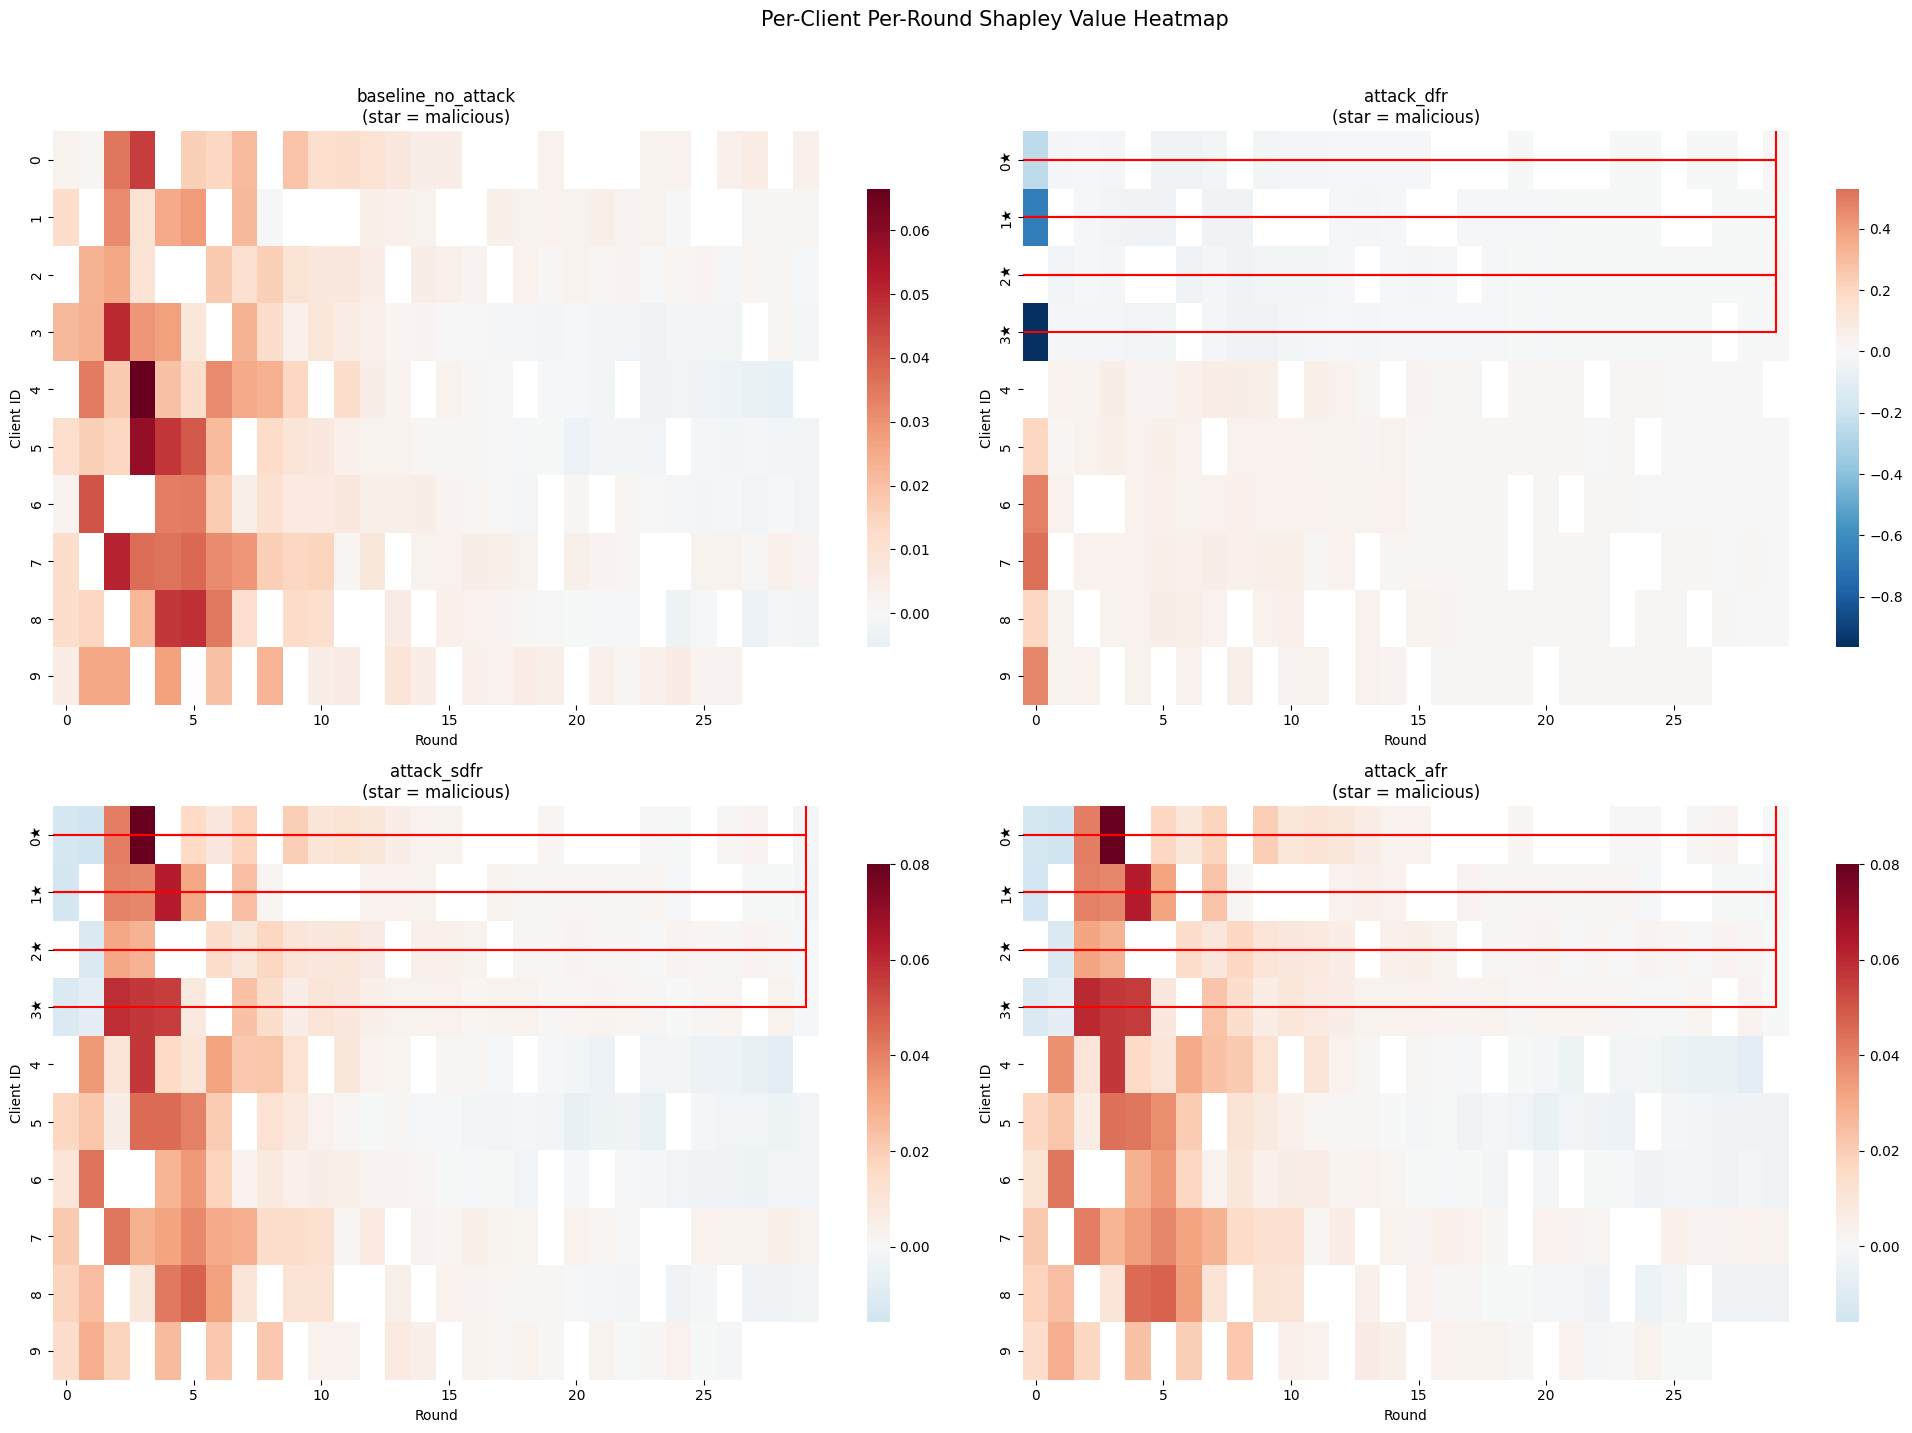

In [33]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()
for idx, (exp_name, _) in enumerate(experiments):
    ax = axes[idx]
    sub = df[df["experiment_name"] == exp_name]
    if sub.empty: ax.set_title(exp_name); continue
    pivot = sub.pivot_table(index="client_id", columns="round",
                            values="round_shapley_value", aggfunc="mean")
    mal_ids = set(sub[sub["is_malicious"]]["client_id"].unique())
    labels = [f"{cid}{chr(9733) if cid in mal_ids else ''}" for cid in pivot.index]
    sns.heatmap(pivot, ax=ax, cmap="RdBu_r", center=0,
                xticklabels=5, yticklabels=labels, cbar_kws={"shrink": 0.8})
    ax.set_xlabel("Round"); ax.set_ylabel("Client ID")
    ax.set_title(f"{exp_name}\n(star = malicious)")
    for i, cid in enumerate(pivot.index):
        if cid in mal_ids:
            ax.add_patch(mpatches.Rectangle((-0.5, i-0.5), pivot.shape[1], 1,
                fill=False, edgecolor="red", linewidth=1.5))
fig.suptitle("Per-Client Per-Round Shapley Value Heatmap", fontsize=15, y=1.02)
fig.tight_layout(); plt.show()

---
## 9. Per-Class SV Fingerprint

Honest clients contribute unevenly across classes (peaked profile); free-riders have near-zero flat profiles.

✅ 图表已自动保存至: results/fig_04_Per-Class_SV_Fingerprint__Honest__peaked.png


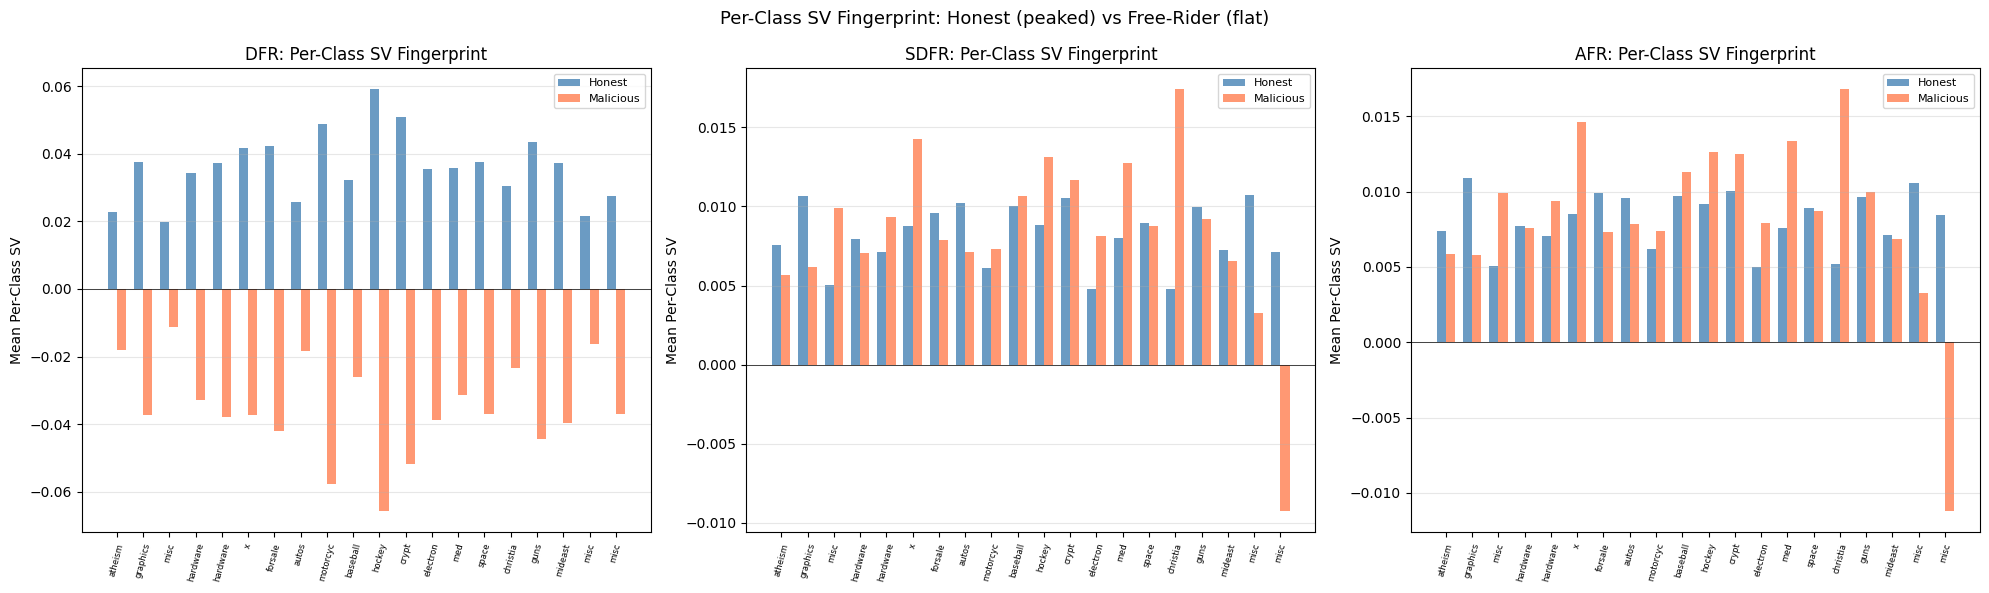

In [34]:
from sklearn.datasets import fetch_20newsgroups
_raw = fetch_20newsgroups(subset="train")
class_names = [n.split(".")[-1][:8] for n in _raw.target_names]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for idx, exp_name in enumerate(attack_names):
    ax = axes[idx]
    sub_pc = df_pc[df_pc["experiment_name"] == exp_name]
    honest_pc = sub_pc[~sub_pc["is_malicious"]][class_cols].mean().values
    mal_pc = sub_pc[sub_pc["is_malicious"]][class_cols].mean().values
    x = np.arange(20)
    w = 0.35
    ax.bar(x - w/2, honest_pc, w, label="Honest", color="steelblue", alpha=0.8)
    ax.bar(x + w/2, mal_pc, w, label="Malicious", color="coral", alpha=0.8)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=75, fontsize=6)
    ax.set_ylabel("Mean Per-Class SV")
    label = exp_name.replace("attack_", "").upper()
    ax.set_title(f"{label}: Per-Class SV Fingerprint")
    ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Per-Class SV Fingerprint: Honest (peaked) vs Free-Rider (flat)", fontsize=13)
fig.tight_layout(); plt.show()

---
## 10. Two-Metric Scatter Plot

X = Class SV Variance, Y = Positive Class SV Sum. Each point = one client (last 5 rounds avg).

✅ 图表已自动保存至: results/fig_05_Two-Metric_Scatter__Honest__circle__vs_M.png


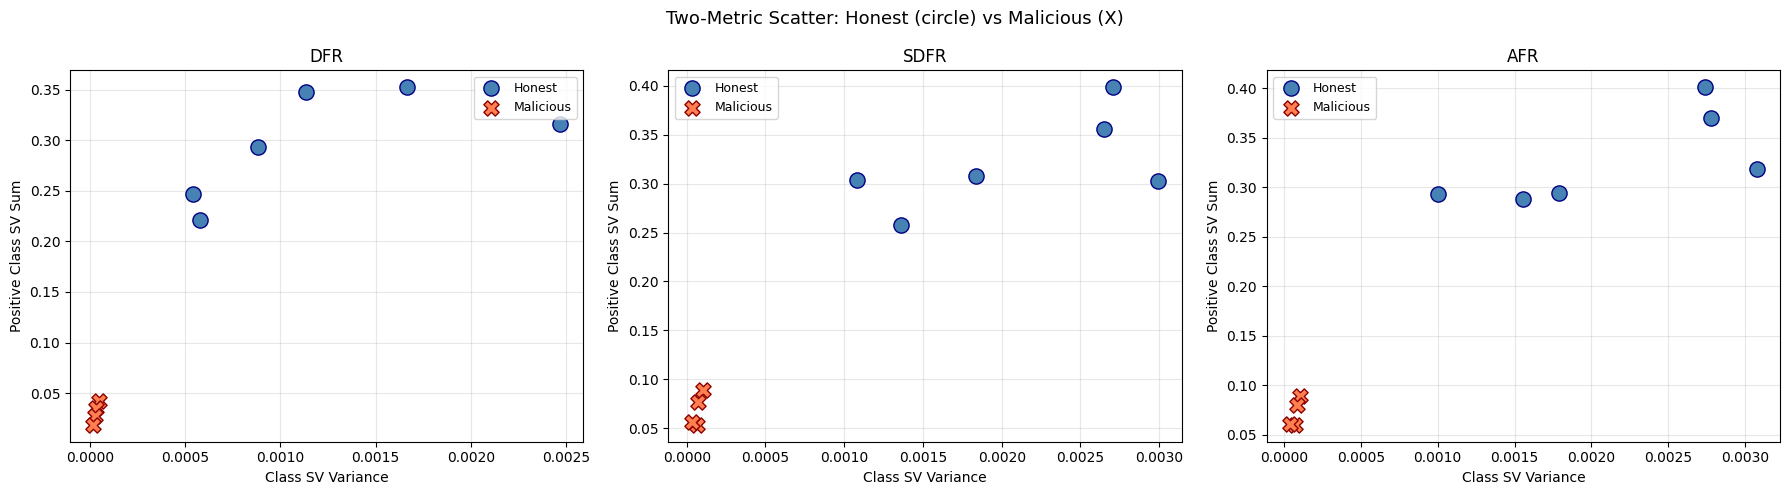

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, exp_name in enumerate(attack_names):
    ax = axes[idx]
    sub = df[df["experiment_name"] == exp_name]
    last_rounds = sub[sub["round"] >= sub["round"].max() - 4]
    client_stats = last_rounds.groupby(["client_id", "is_malicious"]).agg({
        "class_sv_variance": "mean",
        "positive_class_sv_sum": "mean",
    }).reset_index()
    honest = client_stats[~client_stats["is_malicious"]]
    mal = client_stats[client_stats["is_malicious"]]
    ax.scatter(honest["class_sv_variance"], honest["positive_class_sv_sum"],
               c="steelblue", s=120, label="Honest", edgecolors="navy", zorder=5)
    ax.scatter(mal["class_sv_variance"], mal["positive_class_sv_sum"],
               c="coral", s=120, marker="X", label="Malicious", edgecolors="darkred", zorder=5)
    ax.set_xlabel("Class SV Variance"); ax.set_ylabel("Positive Class SV Sum")
    label = exp_name.replace("attack_", "").upper()
    ax.set_title(f"{label}"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("Two-Metric Scatter: Honest (circle) vs Malicious (X)", fontsize=13)
fig.tight_layout(); plt.show()

---
## 11. Box Plots: Metric Distributions

/tmp/ipykernel_15460/1680129869.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_h, data_m], labels=["Honest", "Malicious"], patch_artist=True, widths=0.6)
/tmp/ipykernel_15460/1680129869.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_h, data_m], labels=["Honest", "Malicious"], patch_artist=True, widths=0.6)
/tmp/ipykernel_15460/1680129869.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_h, data_m], labels=["Honest", "Malicious"], patch_artist=True, widths=0.6)
/tmp/ipykernel_15460/1680129869.py:16: MatplotlibDeprecationWarning: The 'labels'

✅ 图表已自动保存至: results/fig_06_Metric_Distributions__Honest_vs_Maliciou.png


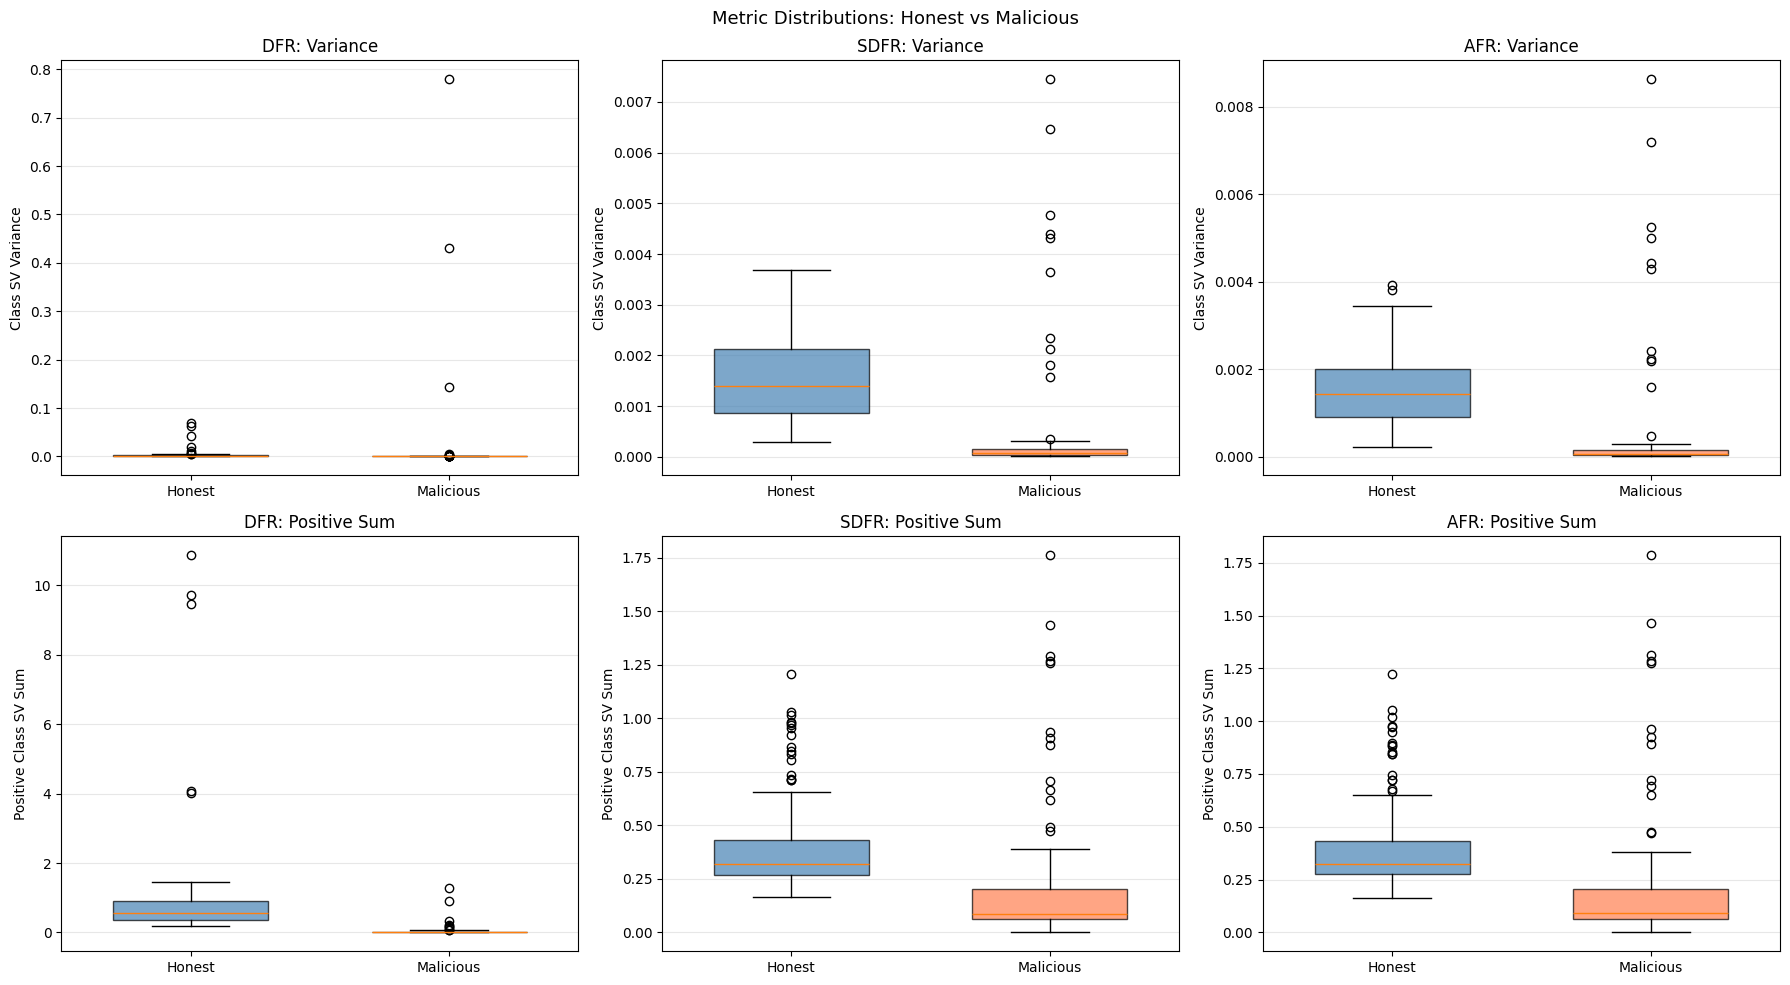

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, exp_name in enumerate(attack_names):
    sub = df[df["experiment_name"] == exp_name]
    label = exp_name.replace("attack_", "").upper()
    ax = axes[0, idx]
    data_h = sub[~sub["is_malicious"]]["class_sv_variance"]
    data_m = sub[sub["is_malicious"]]["class_sv_variance"]
    bp = ax.boxplot([data_h, data_m], labels=["Honest", "Malicious"], patch_artist=True, widths=0.6)
    bp["boxes"][0].set_facecolor("steelblue"); bp["boxes"][1].set_facecolor("coral")
    for b in bp["boxes"]: b.set_alpha(0.7)
    ax.set_ylabel("Class SV Variance"); ax.set_title(f"{label}: Variance")
    ax.grid(True, axis="y", alpha=0.3)
    ax = axes[1, idx]
    data_h = sub[~sub["is_malicious"]]["positive_class_sv_sum"]
    data_m = sub[sub["is_malicious"]]["positive_class_sv_sum"]
    bp = ax.boxplot([data_h, data_m], labels=["Honest", "Malicious"], patch_artist=True, widths=0.6)
    bp["boxes"][0].set_facecolor("steelblue"); bp["boxes"][1].set_facecolor("coral")
    for b in bp["boxes"]: b.set_alpha(0.7)
    ax.set_ylabel("Positive Class SV Sum"); ax.set_title(f"{label}: Positive Sum")
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Metric Distributions: Honest vs Malicious", fontsize=13)
fig.tight_layout(); plt.show()

---
## 12. Per-Class SV Heatmap (Single Client Deep Dive)

DFR experiment: honest vs malicious client across 20 classes x 30 rounds.

✅ 图表已自动保存至: results/fig_07_Per-Class_Per-Round_SV__Honest__varied.png


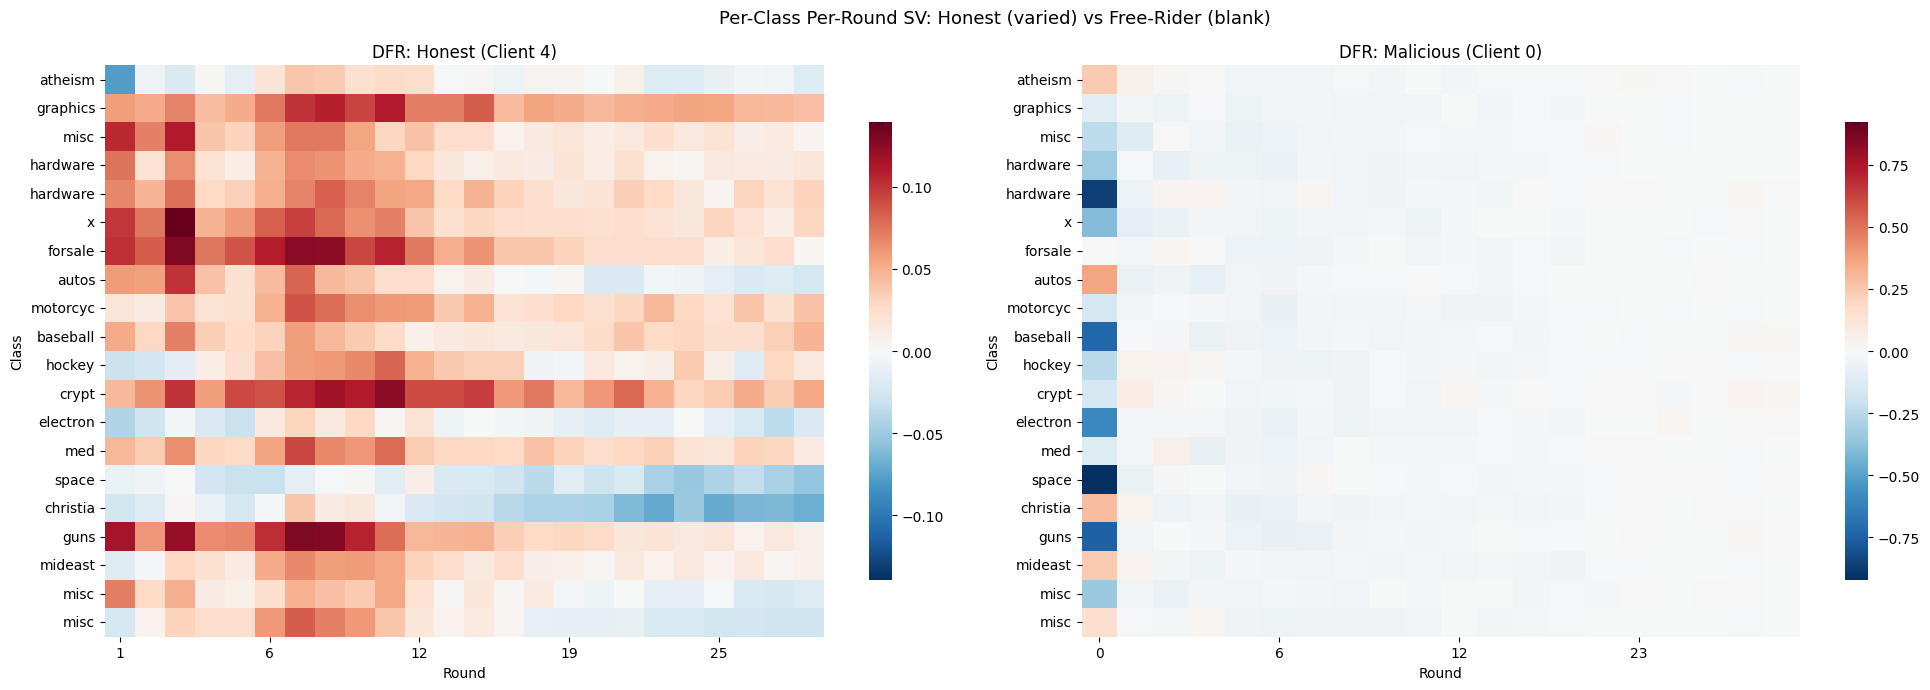

In [37]:
sub_pc = df_pc[df_pc["experiment_name"] == "attack_dfr"]
honest_cids = sorted(sub_pc[~sub_pc["is_malicious"]]["client_id"].unique())
mal_cids = sorted(sub_pc[sub_pc["is_malicious"]]["client_id"].unique())
h_cid, m_cid = honest_cids[0], mal_cids[0]

from sklearn.datasets import fetch_20newsgroups
_raw = fetch_20newsgroups(subset="train")
class_names = [n.split(".")[-1][:8] for n in _raw.target_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
for ax, cid, title in [(ax1, h_cid, f"Honest (Client {h_cid})"),
                        (ax2, m_cid, f"Malicious (Client {m_cid})")]:
    cdata = sub_pc[sub_pc["client_id"] == cid]
    pivot = cdata.pivot_table(index="round", values=class_cols)
    pivot_t = pivot.T
    pivot_t.index = class_names
    vmax = max(abs(pivot_t.values.min()), abs(pivot_t.values.max()), 1e-6)
    sns.heatmap(pivot_t, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                xticklabels=5, cbar_kws={"shrink": 0.8})
    ax.set_xlabel("Round"); ax.set_ylabel("Class")
    ax.set_title(f"DFR: {title}")
fig.suptitle("Per-Class Per-Round SV: Honest (varied) vs Free-Rider (blank)", fontsize=13)
fig.tight_layout(); plt.show()

---
## 13. Core Metrics Over Rounds

✅ 图表已自动保存至: results/fig_08_Per-Class_SV_Variance.png


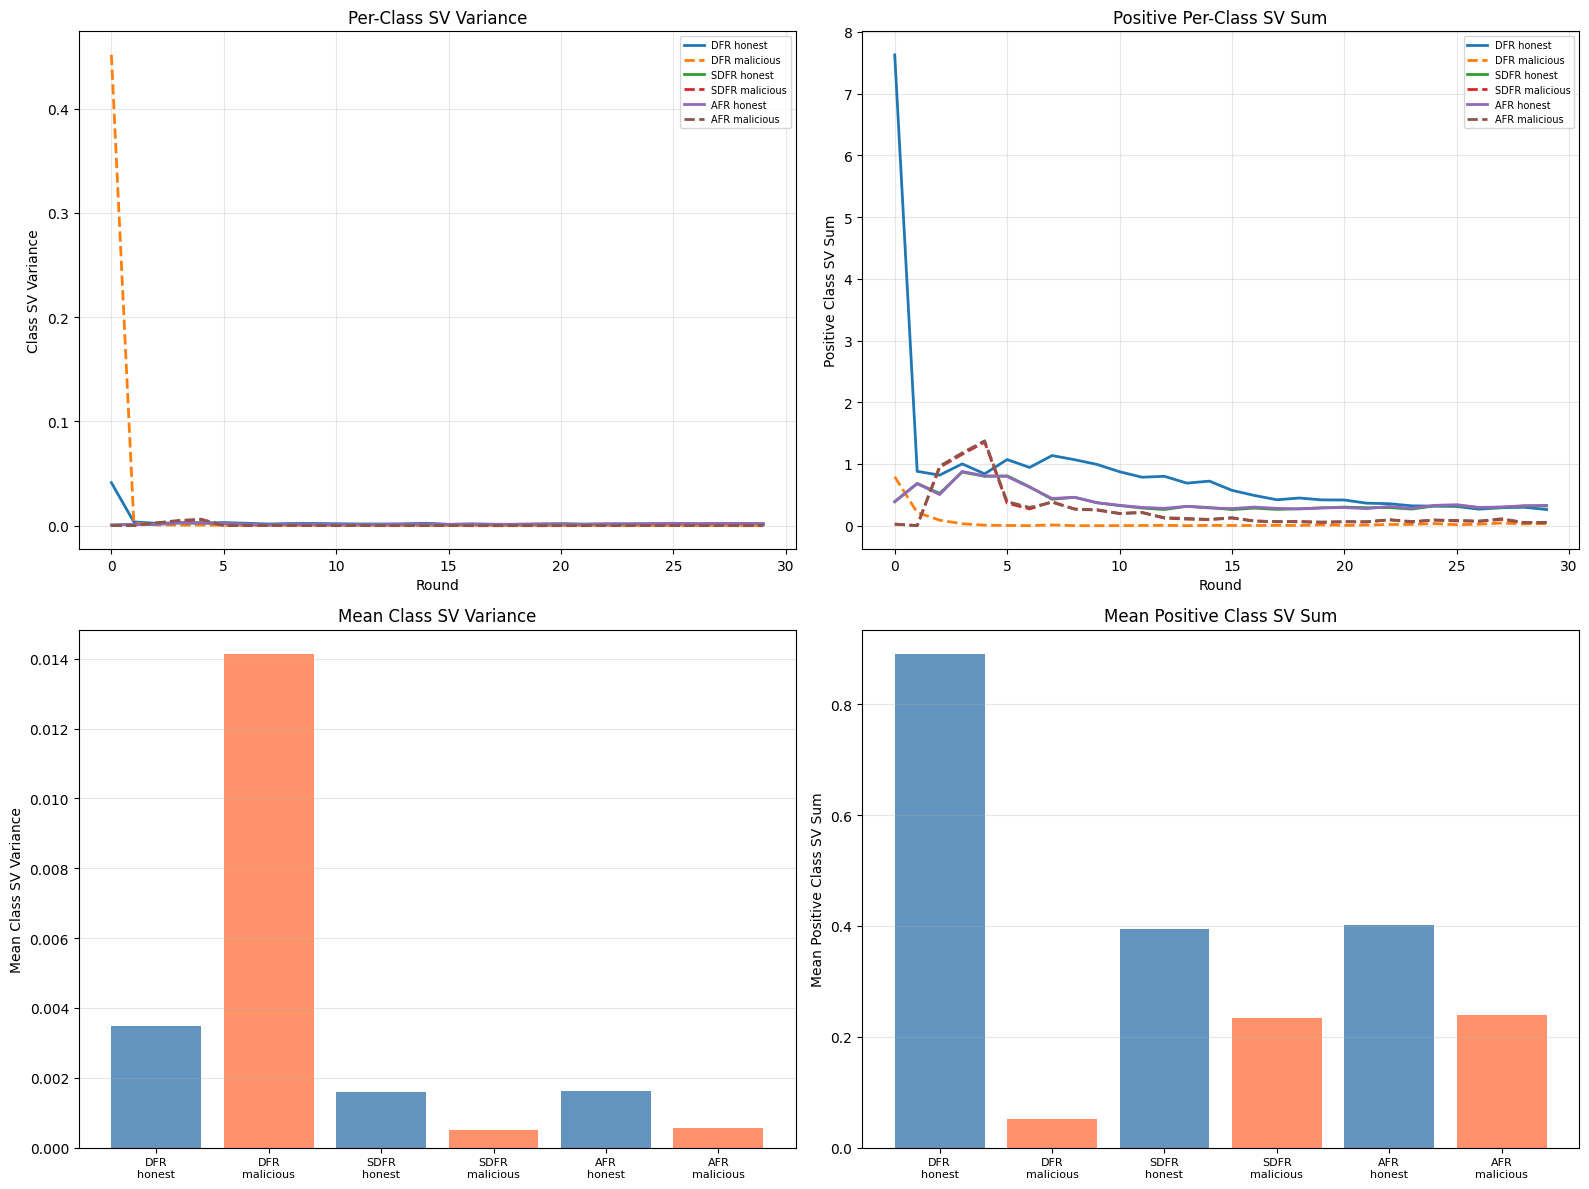

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for exp_name in attack_names:
    sub = df[df["experiment_name"] == exp_name]
    h = sub[~sub["is_malicious"]].groupby("round")["class_sv_variance"].mean()
    m = sub[sub["is_malicious"]].groupby("round")["class_sv_variance"].mean()
    label = exp_name.replace("attack_", "").upper()
    axes[0,0].plot(h.index, h.values, label=f"{label} honest", linewidth=2)
    axes[0,0].plot(m.index, m.values, ls="--", label=f"{label} malicious", linewidth=2)
axes[0,0].set_xlabel("Round"); axes[0,0].set_ylabel("Class SV Variance")
axes[0,0].set_title("Per-Class SV Variance"); axes[0,0].legend(fontsize=7); axes[0,0].grid(True, alpha=0.3)

for exp_name in attack_names:
    sub = df[df["experiment_name"] == exp_name]
    h = sub[~sub["is_malicious"]].groupby("round")["positive_class_sv_sum"].mean()
    m = sub[sub["is_malicious"]].groupby("round")["positive_class_sv_sum"].mean()
    label = exp_name.replace("attack_", "").upper()
    axes[0,1].plot(h.index, h.values, label=f"{label} honest", linewidth=2)
    axes[0,1].plot(m.index, m.values, ls="--", label=f"{label} malicious", linewidth=2)
axes[0,1].set_xlabel("Round"); axes[0,1].set_ylabel("Positive Class SV Sum")
axes[0,1].set_title("Positive Per-Class SV Sum"); axes[0,1].legend(fontsize=7); axes[0,1].grid(True, alpha=0.3)

for metric, ax_idx, ylabel in [
    ("mean_class_sv_variance", (1,0), "Mean Class SV Variance"),
    ("mean_positive_class_sv_sum", (1,1), "Mean Positive Class SV Sum"),
]:
    bl, bv, bc = [], [], []
    for exp_name in attack_names:
        sub = df[df["experiment_name"] == exp_name]
        last = sub[sub["round"] == sub["round"].max()]
        label = exp_name.replace("attack_", "").upper()
        hv = last[~last["is_malicious"]][metric].mean()
        mv = last[last["is_malicious"]][metric].mean()
        bl += [f"{label}\nhonest", f"{label}\nmalicious"]
        bv += [hv, mv]; bc += ["steelblue", "coral"]
    x = np.arange(len(bl))
    axes[ax_idx].bar(x, bv, color=bc, alpha=0.85)
    axes[ax_idx].set_xticks(x); axes[ax_idx].set_xticklabels(bl, fontsize=8)
    axes[ax_idx].set_ylabel(ylabel); axes[ax_idx].set_title(ylabel)
    axes[ax_idx].grid(True, axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

---
## 14. Per-Client Cumulative SV Bar Chart

✅ 图表已自动保存至: results/fig_09_Per-Client_Cumulative_SV__blue_honest__r.png


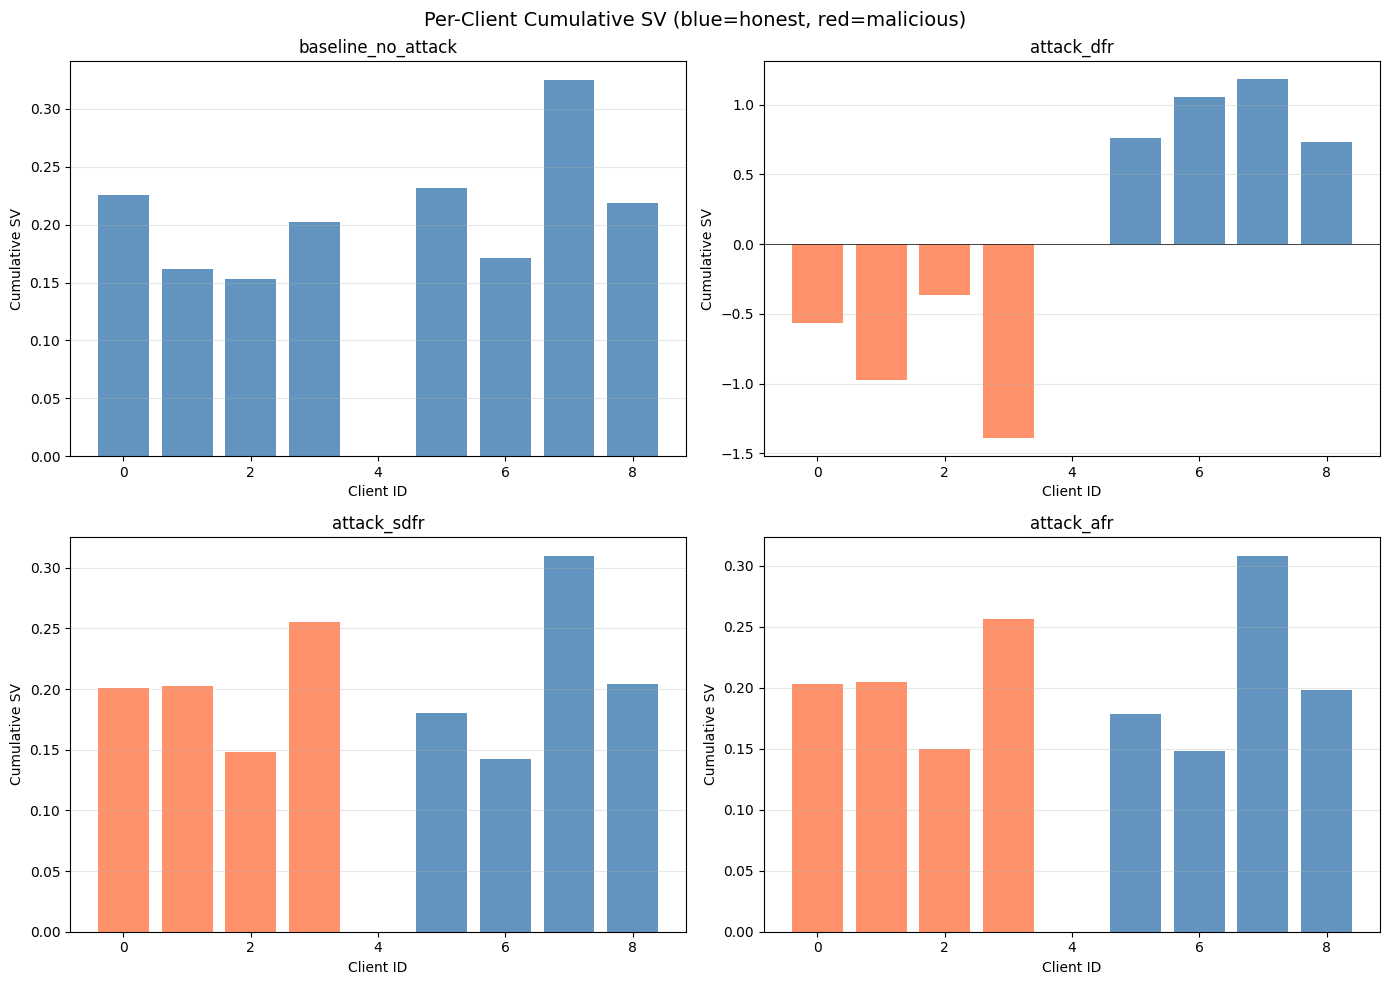

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, (exp_name, _) in enumerate(experiments):
    sub = df[df["experiment_name"] == exp_name]
    if sub.empty: axes[idx].set_title(exp_name); continue
    last = sub[sub["round"] == sub["round"].max()].sort_values("client_id")
    colors = ["coral" if r["is_malicious"] else "steelblue" for _, r in last.iterrows()]
    axes[idx].bar(last["client_id"], last["cumulative_shapley_value"], color=colors, alpha=0.85)
    axes[idx].set_xlabel("Client ID"); axes[idx].set_ylabel("Cumulative SV")
    axes[idx].set_title(exp_name)
    axes[idx].axhline(y=0, color='k', linewidth=0.5); axes[idx].grid(True, axis="y", alpha=0.3)
fig.suptitle("Per-Client Cumulative SV (blue=honest, red=malicious)", fontsize=14)
fig.tight_layout(); plt.show()

---
## 15. Export Excel Report

In [40]:
os.makedirs("results", exist_ok=True)
filepath = export_results(all_details, all_summaries, "results")
print(f"Excel saved: {filepath}")
try:
    from google.colab import files
    files.download(filepath)
    print("Download triggered")
except ImportError:
    print("(Not Colab, skip auto-download)")

Excel saved: results/experiment_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered


---
## Final Summary

In [41]:
print("=" * 110)
print("EXPERIMENT SUMMARY")
print("=" * 110)
print(f"{'Experiment':<22s}  {'Acc':>6s}  {'Loss':>6s}  {'SV_h':>10s}  {'SV_m':>10s}  "
      f"{'Var_h':>10s}  {'Var_m':>10s}  {'PosSum_h':>10s}  {'PosSum_m':>10s}")
print("-" * 110)
for s in all_summaries:
    print(
        f"  {s['experiment_name']:<22s}"
        f"  {s['final_global_accuracy']:.4f}"
        f"  {s['final_global_loss']:.4f}"
        f"  {s['avg_round_shapley_honest']:+.6f}"
        f"  {s['avg_round_shapley_malicious']:+.6f}"
        f"  {s.get('avg_class_sv_variance_honest',0):.2e}"
        f"  {s.get('avg_class_sv_variance_malicious',0):.2e}"
        f"  {s.get('avg_positive_class_sv_sum_honest',0):.6f}"
        f"  {s.get('avg_positive_class_sv_sum_malicious',0):.6f}"
    )
print("=" * 110)
print("\nKey metrics:")
print("  Var: Per-class SV variance (honest > malicious = good)")
print("  PosSum: Positive per-class SV sum (honest > malicious = good)")

EXPERIMENT SUMMARY
Experiment                 Acc    Loss        SV_h        SV_m       Var_h       Var_m    PosSum_h    PosSum_m
--------------------------------------------------------------------------------------------------------------
  baseline_no_attack      0.6893  1.0948  +0.008892  +0.000000  1.29e-03  0.00e+00  0.380464  0.000000
  attack_dfr              0.6646  1.1737  +0.036380  -0.034743  3.05e-03  1.41e-02  0.868098  0.051349
  attack_sdfr             0.6754  1.1985  +0.008281  +0.008682  1.54e-03  4.97e-04  0.397132  0.234415
  attack_afr              0.6751  1.1970  +0.008237  +0.008771  1.58e-03  5.52e-04  0.401290  0.239282

Key metrics:
  Var: Per-class SV variance (honest > malicious = good)
  PosSum: Positive per-class SV sum (honest > malicious = good)


---
## Custom Experiments

| Param | Description | Default |
|-------|-------------|------|
| `num_clients` | Number of clients | 10 |
| `num_rounds` | Communication rounds | 30 |
| `local_epochs` | Local training epochs | 3 |
| `local_lr` | Local learning rate | 0.001 |
| `participation_ratio` | Per-round participation | 0.8 |
| `malicious_ratio` | Malicious ratio | **0.4** |
| `dfr_sigma` | DFR initial noise sigma | **0.5** |
| `dfr_gamma` | DFR decay exponent | **1.0** |
| `afr_e_cos_beta` | AFR expected cosine sim | **0.5** |
| `afr_noisy_frac` | AFR fraction of perturbed params | **0.1** |
| `num_mc_samples` | MC Shapley samples | 30 |
| `iid` | IID partition | True |

In [43]:
import shutil
import os

# 压缩 results 文件夹为 results_archive.zip
shutil.make_archive('results_archive', 'zip', 'results')
print("已成功打包并生成: results_archive.zip")

# 如果运行在 Google Colab 环境下，自动触发下载；否则提供本地下载链接
try:
    from google.colab import files
    files.download('results_archive.zip')
except ImportError:
    from IPython.display import FileLink, display
    display(FileLink('results_archive.zip'))

已成功打包并生成: results_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# Part II: Poisoning Attacks
## Sign-Flipping (SF), A Little Is Enough (ALIE), Label-Flipping (LF)

Same per-class Shapley detection pipeline as the free-rider section above.
Detection metrics: **final per-class SV variance** and **final positive per-class SV sum**.

## P-1. Poisoning Attack Definitions

In [6]:
# ── Poisoning Attack Imports ──────────────────────────────────────────────────
from attacks.sign_flip import sign_flip_attack
from attacks.alie import alie_attack
from attacks.label_flip import create_label_flipped_subset, evaluate_targeted_attack

## P-2. Run All Poisoning Experiments

In [7]:
import os, copy, time
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt._is_patched = False  # ensure auto-save patch re-applies
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

from config import Config
from utils.seed import set_seed
from models.mlp import MLP
from fl.client import FLClient
from fl.server import FLServer
from fl.aggregation import fedavg_aggregate
from contribution.shapley import (
    estimate_round_shapley_per_class, per_class_to_overall,
    compute_class_metrics, _class_weights_from_loader,
)
from detection.utility_score import UtilityScoreTracker
from utils.partition import iid_partition

def create_model_p(input_dim, cfg):
    return MLP(input_dim, cfg.hidden_dim, cfg.num_classes).to(cfg.device)

def run_poisoning_experiment(cfg, train_ds, val_ds, test_ds, input_dim, train_labels):
    set_seed(cfg.seed)
    print(f"\n{'='*70}\n  {cfg.experiment_name}  |  attack={cfg.attack_type}\n{'='*70}")

    partition = iid_partition(train_ds, cfg.num_clients)
    client_datasets = {cid: Subset(train_ds, idx) for cid, idx in partition.items()}

    model_fn = lambda: create_model_p(input_dim, cfg)
    model = model_fn()
    server = FLServer(model, val_ds, test_ds, cfg)
    clients = {cid: FLClient(cid, client_datasets[cid], model_fn, cfg)
               for cid in range(cfg.num_clients)}

    num_mal = int(cfg.num_clients * cfg.malicious_ratio) if cfg.attack_type != "none" else 0
    malicious_ids = set(range(num_mal))

    # LF: prepare flipped datasets
    lf_datasets = {}
    if cfg.attack_type == "lf":
        for cid in malicious_ids:
            lf_datasets[cid], _n_src = create_label_flipped_subset(
                train_ds, partition[cid], cfg.lf_source_class, cfg.lf_target_class)

    utility = UtilityScoreTracker(alpha=cfg.utility_alpha)
    details, accs, losses, asr_list, tacc_list = [], [], [], [], []
    part_cnt = {c: 0 for c in range(cfg.num_clients)}
    cum_sv = {c: 0.0 for c in range(cfg.num_clients)}
    cum_var = {c: [] for c in range(cfg.num_clients)}
    cum_pos = {c: [] for c in range(cfg.num_clients)}
    cum_pc_sv = {c: np.zeros(cfg.num_classes) for c in range(cfg.num_clients)}

    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size)
    eval_model = model_fn()
    cw = _class_weights_from_loader(val_loader, cfg.num_classes)

    for rnd in tqdm(range(cfg.num_rounds), desc=cfg.experiment_name):
        sel = server.select_clients(cfg.num_clients, cfg.participation_ratio)
        gsd = server.get_global_state_dict()
        benign_sel = [c for c in sel if c not in malicious_ids]
        mal_sel = [c for c in sel if c in malicious_ids]

        updates = {}
        for cid in benign_sel:
            part_cnt[cid] += 1
            updates[cid] = clients[cid].train(gsd)

        if cfg.attack_type == "sf":
            for cid in mal_sel:
                part_cnt[cid] += 1
                honest = clients[cid].train(gsd)
                updates[cid] = sign_flip_attack(honest, u=cfg.sf_scale_u)

        elif cfg.attack_type == "alie":
            mal_clean = {}
            for cid in mal_sel:
                part_cnt[cid] += 1
                mal_clean[cid] = clients[cid].train(gsd)
            if mal_sel:
                p_mal, _alie_dbg = alie_attack(
                    {c: updates[c] for c in benign_sel}, mal_clean,
                    len(sel), len(mal_sel), mode=cfg.alie_mode)
                for cid in mal_sel:
                    updates[cid] = p_mal

        elif cfg.attack_type == "lf":
            for cid in mal_sel:
                part_cnt[cid] += 1
                updates[cid] = clients[cid].train_with_dataset(gsd, lf_datasets[cid])

        # Shapley
        pc_sv = estimate_round_shapley_per_class(
            eval_model, updates, gsd, val_loader,
            num_classes=cfg.num_classes, server_lr=cfg.server_lr,
            num_mc_samples=cfg.num_mc_samples, device=cfg.device)
        sv = per_class_to_overall(pc_sv, cw)
        cm = compute_class_metrics(pc_sv)
        for cid in sel:
            if cid in pc_sv:
                cum_pc_sv[cid] += pc_sv[cid]
        utility.update(sv)

        new_sd = fedavg_aggregate(gsd, updates, cfg.server_lr)
        server.update_global_model(new_sd)
        tl, ta = server.evaluate()
        accs.append(ta); losses.append(tl)

        asr_val, tacc_val = 0.0, 0.0
        if cfg.attack_type == "lf":
            eval_model.load_state_dict(server.get_global_state_dict())
            asr_val, tacc_val, _src_total = evaluate_targeted_attack(
                eval_model, test_loader, cfg.lf_source_class, cfg.lf_target_class, cfg.device)
            asr_list.append(asr_val); tacc_list.append(tacc_val)

        for cid in sel:
            s = sv.get(cid, 0.0); cum_sv[cid] += s; pc = part_cnt[cid]
            m = cm.get(cid, {}); cv = m.get("class_sv_variance", 0.0); ps = m.get("positive_class_sv_sum", 0.0)
            cum_var[cid].append(cv); cum_pos[cid].append(ps)
            details.append(dict(
                experiment_name=cfg.experiment_name, attack_type=cfg.attack_type,
                round=rnd, client_id=cid, is_malicious=cid in malicious_ids,
                participation_count_so_far=pc, round_shapley_value=s,
                cumulative_shapley_value=cum_sv[cid],
                mean_shapley_value=cum_sv[cid]/pc,
                class_sv_variance=cv, positive_class_sv_sum=ps,
                mean_class_sv_variance=float(np.mean(cum_var[cid])),
                mean_positive_class_sv_sum=float(np.mean(cum_pos[cid])),
                utility_score=utility.scores.get(cid, 0.0)))

    honest_ids = [c for c in range(cfg.num_clients) if c not in malicious_ids]
    avg_sv = lambda ids: float(np.mean([cum_sv[c]/max(part_cnt[c],1) for c in ids])) if ids else 0.0
    avg_cum = lambda ids: float(np.mean([cum_sv[c] for c in ids])) if ids else 0.0
    avg_m = lambda ids, st: float(np.mean([np.mean(st[c]) if st[c] else 0.0 for c in ids])) if ids else 0.0
    fvar = lambda ids: float(np.mean([np.var(cum_pc_sv[c]) for c in ids])) if ids else 0.0
    fpos = lambda ids: float(np.mean([np.sum(cum_pc_sv[c][cum_pc_sv[c]>0]) for c in ids])) if ids else 0.0

    summary = dict(
        experiment_name=cfg.experiment_name, attack_type=cfg.attack_type,
        malicious_ratio=cfg.malicious_ratio if num_mal else 0.0,
        final_global_accuracy=accs[-1], final_global_loss=losses[-1],
        avg_round_shapley_honest=avg_sv(honest_ids),
        avg_round_shapley_malicious=avg_sv(list(malicious_ids)),
        avg_cumulative_shapley_honest=avg_cum(honest_ids),
        avg_cumulative_shapley_malicious=avg_cum(list(malicious_ids)),
        avg_class_sv_variance_honest=avg_m(honest_ids, cum_var),
        avg_class_sv_variance_malicious=avg_m(list(malicious_ids), cum_var),
        avg_positive_sv_sum_honest=avg_m(honest_ids, cum_pos),
        avg_positive_sv_sum_malicious=avg_m(list(malicious_ids), cum_pos),
        final_per_class_sv_variance_honest=fvar(honest_ids),
        final_per_class_sv_variance_malicious=fvar(list(malicious_ids)),
        final_positive_per_class_sv_sum_honest=fpos(honest_ids),
        final_positive_per_class_sv_sum_malicious=fpos(list(malicious_ids)),
        attack_effective="", notes="")
    if cfg.attack_type == "lf" and asr_list:
        summary["final_asr"] = asr_list[-1]
        summary["final_tacc"] = tacc_list[-1]

    pcf = [dict(experiment_name=cfg.experiment_name, client_id=c,
                is_malicious=c in malicious_ids, cumulative_sv=cum_sv[c],
                final_per_class_sv_variance=float(np.var(cum_pc_sv[c])),
                final_positive_per_class_sv_sum=float(np.sum(cum_pc_sv[c][cum_pc_sv[c]>0])),
                participation_count=part_cnt[c])
           for c in range(cfg.num_clients)]
    debug_info = {'alie_rounds': [], 'lf_rounds': [], 'sf_rounds': [], 'lf_client_stats': {}}
    return details, summary, accs, losses, asr_list, tacc_list, pcf, cum_pc_sv, debug_info

print("run_poisoning_experiment() defined.")

run_poisoning_experiment() defined.


In [8]:
# ── Run all 4 poisoning experiments ──────────────────────────────────────────
base_p = Config(
    num_clients=20, num_rounds=30, local_epochs=3,
    local_lr=0.001, server_lr=1.0, participation_ratio=0.5,
    batch_size=64, hidden_dim=256, num_classes=20,
    max_features=10000, val_ratio=0.1, iid=True,
    malicious_ratio=0.3, num_mc_samples=30,
    seed=42, device="cpu", results_dir="results_poisoning",
    sf_scale_u=-1.0, alie_mode="svrfl",
    lf_source_class=0, lf_target_class=10,
)

set_seed(base_p.seed)
# Reload data with 20-client partitioning seed
p_train, p_val, p_test, p_indim, p_labels = load_newsgroups(
    max_features=base_p.max_features, val_ratio=base_p.val_ratio)
print(f"Data: input_dim={p_indim}, train={len(p_train)}, val={len(p_val)}, test={len(p_test)}")

experiments_p = [
    ("baseline_no_attack", "none"),
    ("attack_sf", "sf"),
    ("attack_alie", "alie"),
    ("attack_lf", "lf"),
]

p_all_details, p_all_summaries = [], []
p_all_curves, p_all_pclient, p_all_cumpc = {}, {}, {}
p_all_pclient_flat = []

t0 = time.time()
for ename, atype in experiments_p:
    c = copy.deepcopy(base_p)
    c.experiment_name = ename; c.attack_type = atype
    det, summ, ac, lo, asr, tacc, pcf, cpc, _dbg = run_poisoning_experiment(
        c, p_train, p_val, p_test, p_indim, p_labels)
    p_all_details.extend(det); p_all_summaries.append(summ)
    p_all_curves[ename] = dict(acc=ac, loss=lo, asr=asr, tacc=tacc)
    p_all_pclient[ename] = pcf; p_all_cumpc[ename] = cpc
    p_all_pclient_flat.extend(pcf)

print(f"\nAll experiments done in {time.time()-t0:.0f}s")

# mark effectiveness
bl_acc = p_all_summaries[0]["final_global_accuracy"]
for s in p_all_summaries[1:]:
    drop = bl_acc - s["final_global_accuracy"]
    s["attack_effective"] = drop > 0.02
    s["notes"] = f"acc drop={drop:.4f}"

p_num_mal = int(base_p.num_clients * base_p.malicious_ratio)
p_mal_ids = set(range(p_num_mal))
p_attack_names = [n for n, _ in experiments_p if n != "baseline_no_attack"]

Data: input_dim=10000, train=10183, val=1131, test=7532

  baseline_no_attack  |  attack=none


baseline_no_attack:   0%|          | 0/30 [00:00<?, ?it/s]


  attack_sf  |  attack=sf


attack_sf:   0%|          | 0/30 [00:00<?, ?it/s]


  attack_alie  |  attack=alie


attack_alie:   0%|          | 0/30 [00:00<?, ?it/s]


  attack_lf  |  attack=lf


attack_lf:   0%|          | 0/30 [00:00<?, ?it/s]


All experiments done in 823s


## P-3. Poisoning Summary Table

In [24]:
df_p_summary = pd.DataFrame(p_all_summaries)
display_cols = [
    'experiment_name', 'final_global_accuracy', 'final_global_loss',
    'avg_round_shapley_honest', 'avg_round_shapley_malicious',
    'final_per_class_sv_variance_honest', 'final_per_class_sv_variance_malicious',
    'final_positive_per_class_sv_sum_honest', 'final_positive_per_class_sv_sum_malicious',
]
if 'final_asr' in df_p_summary.columns:
    display_cols += ['final_asr', 'final_tacc']
df_p_summary[[c for c in display_cols if c in df_p_summary.columns]]

,experiment_name,final_global_accuracy,final_global_loss,avg_round_shapley_honest,avg_round_shapley_malicious,final_per_class_sv_variance_honest,final_per_class_sv_variance_malicious,final_positive_per_class_sv_sum_honest,final_positive_per_class_sv_sum_malicious,final_asr,final_tacc
0,baseline_no_attack,0.683617,1.119688,0.006710,0.000000,0.211535,0.000000,4.631699,0.000000,NaN,NaN
1,attack_sf,0.594264,1.774378,0.023663,-0.040732,0.216994,0.394767,8.336626,1.242431,NaN,NaN
2,attack_alie,0.675385,1.162654,0.007547,0.004065,0.151437,0.000872,4.322100,1.262362,NaN,NaN
3,attack_lf,0.678040,1.135454,0.009706,-0.000624,0.271482,0.671339,5.738321,4.748215,0.015674,0.269592


## P-4. Global Performance Curves

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
for name, d in p_all_curves.items():
    ax1.plot(d["acc"], label=name)
    ax2.plot(d["loss"], label=name)
ax1.set_xlabel("Round"); ax1.set_ylabel("Test Accuracy")
ax1.set_title("Poisoning: Test Accuracy"); ax1.legend(); ax1.grid(True)
ax2.set_xlabel("Round"); ax2.set_ylabel("Test Loss")
ax2.set_title("Poisoning: Test Loss"); ax2.legend(); ax2.grid(True)
fig.tight_layout(); plt.show()

✅ 图表已自动保存至: results/fig_01_Poisoning__Test_Accuracy.png


## P-5. LF: ASR & TACC Curves

In [26]:
for name, d in p_all_curves.items():
    if d.get("asr"):
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
        a1.plot(d["asr"], color="red"); a1.set_xlabel("Round"); a1.set_ylabel("ASR")
        a1.set_title(f"{name}: Attack Success Rate"); a1.grid(True); a1.set_ylim([-0.05,1.05])
        a2.plot(d["tacc"], color="green"); a2.set_xlabel("Round"); a2.set_ylabel("TACC")
        a2.set_title(f"{name}: Source-Class Accuracy"); a2.grid(True); a2.set_ylim([-0.05,1.05])
        fig.tight_layout(); plt.show()

✅ 图表已自动保存至: results/fig_02_attack_lf__Attack_Success_Rate.png


## P-6. Standard SV: Round-Level & Cumulative

In [27]:
df_p = pd.DataFrame(p_all_details)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for en in p_attack_names:
    sub = df_p[df_p["experiment_name"]==en]
    if sub.empty: continue
    h = sub[~sub["is_malicious"]].groupby("round")["round_shapley_value"].mean()
    m = sub[sub["is_malicious"]].groupby("round")["round_shapley_value"].mean()
    lb = en.replace("attack_","").upper()
    axes[0].plot(h.index, h.values, label=f"{lb} honest")
    axes[0].plot(m.index, m.values, ls="--", label=f"{lb} malicious")
axes[0].set_xlabel("Round"); axes[0].set_ylabel("Mean Round SV")
axes[0].set_title("Round-Level SV: Honest vs Malicious"); axes[0].legend(fontsize=8)
axes[0].axhline(y=0, color="k", lw=0.5); axes[0].grid(True)

for en in p_attack_names:
    sub = df_p[df_p["experiment_name"]==en]
    if sub.empty: continue
    h = sub[~sub["is_malicious"]].groupby("round")["cumulative_shapley_value"].mean()
    m = sub[sub["is_malicious"]].groupby("round")["cumulative_shapley_value"].mean()
    lb = en.replace("attack_","").upper()
    axes[1].plot(h.index, h.values, label=f"{lb} honest")
    axes[1].plot(m.index, m.values, ls="--", label=f"{lb} malicious")
axes[1].set_xlabel("Round"); axes[1].set_ylabel("Mean Cumulative SV")
axes[1].set_title("Cumulative SV: Honest vs Malicious"); axes[1].legend(fontsize=8)
axes[1].axhline(y=0, color="k", lw=0.5); axes[1].grid(True)
fig.tight_layout(); plt.show()

/tmp/ipykernel_42257/2451193603.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))


✅ 图表已自动保存至: results/fig_03_Round-Level_SV__Honest_vs_Malicious.png


## P-7. Per-Client Cumulative SV Bar Charts

In [28]:
from matplotlib.patches import Patch
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
all_exp = ["baseline_no_attack"] + p_attack_names
for idx, en in enumerate(all_exp):
    sub = df_p[df_p["experiment_name"]==en]
    if sub.empty: continue
    lr = sub["round"].max()
    last = sub[sub["round"]==lr].drop_duplicates("client_id").sort_values("client_id")
    colors = ["coral" if m else "steelblue" for m in last["is_malicious"]]
    axes[idx].bar(last["client_id"].values, last["cumulative_shapley_value"].values,
                  color=colors, alpha=0.85)
    axes[idx].set_xlabel("Client ID"); axes[idx].set_ylabel("Cum SV")
    axes[idx].set_title(en.replace("attack_","").upper())
    axes[idx].axhline(y=0, color="k", lw=0.5); axes[idx].grid(True, axis="y")
    axes[idx].legend(handles=[Patch(color="steelblue",label="Honest"),
                              Patch(color="coral",label="Malicious")])
fig.tight_layout(); plt.show()

✅ 图表已自动保存至: results/fig_04_BASELINE_NO_ATTACK.png


## P-8. SV Heatmaps (Per-Client Per-Round)

In [29]:
for en in p_attack_names:
    sub = df_p[df_p["experiment_name"]==en]
    if sub.empty: continue
    pivot = sub.pivot_table(index="client_id", columns="round",
                            values="round_shapley_value", aggfunc="first").fillna(0)
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", interpolation="nearest")
    ax.set_xlabel("Round"); ax.set_ylabel("Client ID")
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    lb = en.replace("attack_","").upper()
    ax.set_title(f"{lb}: Per-Client Per-Round SV")
    plt.colorbar(im, ax=ax, label="Round SV")
    for i, cid in enumerate(pivot.index):
        if cid in p_mal_ids:
            ax.text(-1.5, i, "★", fontsize=10, color="red", ha="center", va="center")
    fig.tight_layout(); plt.show()

✅ 图表已自动保存至: results/fig_05_SF__Per-Client_Per-Round_SV.png
✅ 图表已自动保存至: results/fig_06_ALIE__Per-Client_Per-Round_SV.png
✅ 图表已自动保存至: results/fig_07_LF__Per-Client_Per-Round_SV.png


## P-9. Final Per-Class SV Fingerprints

In [30]:
nc = base_p.num_classes
for en in p_attack_names:
    if en not in p_all_cumpc: continue
    pc = p_all_cumpc[en]
    hc = [c for c in pc if c not in p_mal_ids]
    mc = [c for c in pc if c in p_mal_ids]
    if not hc or not mc: continue
    mh = np.mean([pc[c] for c in hc], axis=0)
    mm = np.mean([pc[c] for c in mc], axis=0)
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(nc); w = 0.35
    ax.bar(x-w/2, mh, w, color="steelblue", alpha=.85, label="Honest")
    ax.bar(x+w/2, mm, w, color="coral", alpha=.85, label="Malicious")
    ax.set_xlabel("Class"); ax.set_ylabel("Cumulative Per-Class SV")
    ax.set_title(f"{en.replace('attack_','').upper()}: Per-Class SV Fingerprint")
    ax.set_xticks(x); ax.legend(); ax.grid(True, axis="y")
    fig.tight_layout(); plt.show()

✅ 图表已自动保存至: results/fig_08_SF__Per-Class_SV_Fingerprint.png
✅ 图表已自动保存至: results/fig_09_ALIE__Per-Class_SV_Fingerprint.png
✅ 图表已自动保存至: results/fig_10_LF__Per-Class_SV_Fingerprint.png


## P-10. Detection Box Plots & Scatter

In [31]:
for en in p_attack_names:
    if en not in p_all_pclient: continue
    pcf = pd.DataFrame(p_all_pclient[en])
    lb = en.replace("attack_","").upper()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # Box: variance
    hv = pcf[~pcf["is_malicious"]]["final_per_class_sv_variance"]
    mv = pcf[pcf["is_malicious"]]["final_per_class_sv_variance"]
    bp = axes[0].boxplot([hv, mv], labels=["Honest","Malicious"], patch_artist=True)
    bp["boxes"][0].set_facecolor("steelblue"); bp["boxes"][1].set_facecolor("coral")
    axes[0].set_ylabel("Final Per-Class SV Variance"); axes[0].set_title(f"{lb}: Variance")
    axes[0].grid(True, axis="y")

    # Box: positive sum
    hp = pcf[~pcf["is_malicious"]]["final_positive_per_class_sv_sum"]
    mp = pcf[pcf["is_malicious"]]["final_positive_per_class_sv_sum"]
    bp2 = axes[1].boxplot([hp, mp], labels=["Honest","Malicious"], patch_artist=True)
    bp2["boxes"][0].set_facecolor("steelblue"); bp2["boxes"][1].set_facecolor("coral")
    axes[1].set_ylabel("Final Pos Per-Class SV Sum"); axes[1].set_title(f"{lb}: Pos Sum")
    axes[1].grid(True, axis="y")

    # Scatter
    hd = pcf[~pcf["is_malicious"]]
    md2 = pcf[pcf["is_malicious"]]
    axes[2].scatter(hd["final_per_class_sv_variance"], hd["final_positive_per_class_sv_sum"],
                    c="steelblue", marker="o", s=80, label="Honest", zorder=3)
    axes[2].scatter(md2["final_per_class_sv_variance"], md2["final_positive_per_class_sv_sum"],
                    c="coral", marker="x", s=100, label="Malicious", zorder=3)
    axes[2].set_xlabel("Variance"); axes[2].set_ylabel("Positive Sum")
    axes[2].set_title(f"{lb}: Two-Metric Scatter"); axes[2].legend(); axes[2].grid(True)

    fig.tight_layout(); plt.show()

/tmp/ipykernel_42257/3706469739.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([hv, mv], labels=["Honest","Malicious"], patch_artist=True)
/tmp/ipykernel_42257/3706469739.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([hp, mp], labels=["Honest","Malicious"], patch_artist=True)


✅ 图表已自动保存至: results/fig_11_SF__Variance.png


/tmp/ipykernel_42257/3706469739.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([hv, mv], labels=["Honest","Malicious"], patch_artist=True)
/tmp/ipykernel_42257/3706469739.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([hp, mp], labels=["Honest","Malicious"], patch_artist=True)


✅ 图表已自动保存至: results/fig_12_ALIE__Variance.png


/tmp/ipykernel_42257/3706469739.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([hv, mv], labels=["Honest","Malicious"], patch_artist=True)
/tmp/ipykernel_42257/3706469739.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([hp, mp], labels=["Honest","Malicious"], patch_artist=True)


✅ 图表已自动保存至: results/fig_13_LF__Variance.png


## P-11. Multi-Attack Summary

In [32]:
atk_only = [a for a in p_attack_names if "baseline" not in a]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labs, hv, mv, hp, mp = [], [], [], [], []
for en in atk_only:
    if en not in p_all_pclient: continue
    pcf = pd.DataFrame(p_all_pclient[en])
    labs.append(en.replace("attack_","").upper())
    hv.append(pcf[~pcf["is_malicious"]]["final_per_class_sv_variance"].mean())
    mv.append(pcf[pcf["is_malicious"]]["final_per_class_sv_variance"].mean())
    hp.append(pcf[~pcf["is_malicious"]]["final_positive_per_class_sv_sum"].mean())
    mp.append(pcf[pcf["is_malicious"]]["final_positive_per_class_sv_sum"].mean())
if labs:
    x = np.arange(len(labs)); w = 0.35
    axes[0].bar(x-w/2, hv, w, color="steelblue", label="Honest")
    axes[0].bar(x+w/2, mv, w, color="coral", label="Malicious")
    axes[0].set_xticks(x); axes[0].set_xticklabels(labs)
    axes[0].set_ylabel("Mean Final Per-Class SV Var"); axes[0].set_title("Variance by Attack")
    axes[0].legend(); axes[0].grid(True, axis="y")
    axes[1].bar(x-w/2, hp, w, color="steelblue", label="Honest")
    axes[1].bar(x+w/2, mp, w, color="coral", label="Malicious")
    axes[1].set_xticks(x); axes[1].set_xticklabels(labs)
    axes[1].set_ylabel("Mean Final Pos Per-Class SV Sum"); axes[1].set_title("Pos Sum by Attack")
    axes[1].legend(); axes[1].grid(True, axis="y")
fig.tight_layout(); plt.show()

✅ 图表已自动保存至: results/fig_14_Variance_by_Attack.png


## P-12. Export Poisoning Results

In [33]:
os.makedirs("results_poisoning", exist_ok=True)
df_det = pd.DataFrame(p_all_details)
df_sum = pd.DataFrame(p_all_summaries)
df_pcf = pd.DataFrame(p_all_pclient_flat)
with pd.ExcelWriter("results_poisoning/poisoning_results.xlsx", engine="openpyxl") as w:
    df_det.to_excel(w, sheet_name="round_details", index=False)
    df_sum.to_excel(w, sheet_name="experiment_summary", index=False)
    df_pcf.to_excel(w, sheet_name="per_client_final", index=False)
print("Exported to results_poisoning/poisoning_results.xlsx")

Exported to results_poisoning/poisoning_results.xlsx


## P-13. Detection Analysis

In [34]:
print("=" * 72)
print("POISONING DETECTION ANALYSIS")
print("=" * 72)
for en in p_attack_names:
    s = next(x for x in p_all_summaries if x["experiment_name"]==en)
    lb = en.replace("attack_","").upper()
    print(f"\n{'─'*60}\n  {lb}\n{'─'*60}")
    sv_h = s["avg_round_shapley_honest"]; sv_m = s["avg_round_shapley_malicious"]
    ch = s["avg_cumulative_shapley_honest"]; cm_ = s["avg_cumulative_shapley_malicious"]
    fvh = s["final_per_class_sv_variance_honest"]; fvm = s["final_per_class_sv_variance_malicious"]
    fph = s["final_positive_per_class_sv_sum_honest"]; fpm = s["final_positive_per_class_sv_sum_malicious"]

    rd = "YES" if abs(sv_h-sv_m)/max(abs(sv_h),1e-9) > 0.3 else "WEAK/NO"
    cd = "YES" if abs(ch-cm_)/max(abs(ch),1e-9) > 0.3 else "WEAK/NO"
    vr = fvm/max(fvh,1e-12); vd = "YES" if vr>2 or vr<0.5 else "WEAK/NO"
    pr = fpm/max(fph,1e-9) if fph>0 else 0; pd_ = "YES" if pr<0.5 or pr>2 else "WEAK/NO"
    jd = "YES" if vd=="YES" or pd_=="YES" else "WEAK/NO"

    print(f"  Round SV detects?        {rd}  (H={sv_h:.6f} M={sv_m:.6f})")
    print(f"  Cumul SV detects?        {cd}  (H={ch:.6f} M={cm_:.6f})")
    print(f"  Per-class var detects?   {vd}  (H={fvh:.2e} M={fvm:.2e} ratio={vr:.2f})")
    print(f"  Pos per-class sum?       {pd_}  (H={fph:.6f} M={fpm:.6f} ratio={pr:.2f})")
    print(f"  Joint two-metric?        {jd}")
print("=" * 72)

POISONING DETECTION ANALYSIS

────────────────────────────────────────────────────────────
  SF
────────────────────────────────────────────────────────────
  Round SV detects?        YES  (H=0.023663 M=-0.040732)
  Cumul SV detects?        YES  (H=0.355765 M=-0.612457)
  Per-class var detects?   WEAK/NO  (H=2.17e-01 M=3.95e-01 ratio=1.82)
  Pos per-class sum?       YES  (H=8.336626 M=1.242431 ratio=0.15)
  Joint two-metric?        YES

────────────────────────────────────────────────────────────
  ALIE
────────────────────────────────────────────────────────────
  Round SV detects?        YES  (H=0.007547 M=0.004065)
  Cumul SV detects?        YES  (H=0.113229 M=0.062306)
  Per-class var detects?   YES  (H=1.51e-01 M=8.72e-04 ratio=0.01)
  Pos per-class sum?       YES  (H=4.322100 M=1.262362 ratio=0.29)
  Joint two-metric?        YES

────────────────────────────────────────────────────────────
  LF
────────────────────────────────────────────────────────────
  Round SV detects?      

In [35]:
import shutil, os

zip_path = 'results.zip'
shutil.make_archive('results', 'zip', 'results')
print(f'✅ 已打包: {zip_path}  ({os.path.getsize(zip_path)/1024:.1f} KB)')

try:
    from google.colab import files
    files.download(zip_path)
    print('⬇️  下载已触发')
except ImportError:
    print(f'📁 本地环境：文件已保存至 {os.path.abspath(zip_path)}')


✅ 已打包: results.zip  (4084.1 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  下载已触发


In [ ]:
import os, zipfile

project_dir = os.getcwd()
# 输出到项目目录的上一级，避免把自身打包进去
zip_out = os.path.join(os.path.dirname(project_dir), '20NEWS_project.zip')

EXCLUDE_DIRS = {'data', '__pycache__', '.git', '.ipynb_checkpoints'}
EXCLUDE_EXTS = {'.zip', '.pyc', '.pkl', '.npy', '.npz'}

with zipfile.ZipFile(zip_out, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(project_dir):
        dirs[:] = [d for d in dirs if d not in EXCLUDE_DIRS]
        for file in files:
            if os.path.splitext(file)[1] in EXCLUDE_EXTS:
                continue
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, os.path.dirname(project_dir))
            zf.write(full_path, arcname)

print(f'✅ 已打包: {zip_out}  ({os.path.getsize(zip_out)/1024/1024:.1f} MB)')

try:
    from google.colab import files
    files.download(zip_out)
    print('⬇️  下载已触发')
except ImportError:
    print(f'📁 本地环境：文件已保存至 {zip_out}')


: 